# 05 — Factoring Polynomials

**Topic 5 of the syllabus (Review).**

In notebook 04 we learned how to **build** polynomials: add them, subtract them, and
above all **multiply** them. Multiplying is the easy direction. You follow the rules and
you always get an answer.

This notebook is about the **hard direction**: going backwards.

$$\underbrace{(x+2)(x+3)}_{\text{what we want to find}} \;\xrightarrow{\;\text{multiply — easy}\;}\;
\underbrace{x^{2}+5x+6}_{\text{what we are given}}$$

$$\underbrace{x^{2}+5x+6}_{\text{what we are given}} \;\xrightarrow{\;\textbf{factor — hard}\;}\;
\underbrace{(x+2)(x+3)}_{\text{what we want to find}}$$

**To factor** a polynomial means to write it as a **product** of simpler polynomials.
The word *factor* is the same word we used for numbers: $6 = 2\times 3$, so $2$ and $3$ are
factors of $6$. Here $(x+2)$ and $(x+3)$ are factors of $x^{2}+5x+6$.

Why do we care so much about a product? Because of one small fact that we proved all the
way back in notebook 01 (Theorem B):

> **A product is zero only when one of its parts is zero.**

A sum tells you nothing. If $x^{2}+5x+6 = 0$, you cannot say anything about $x$ just by
looking. But if $(x+2)(x+3) = 0$, then immediately $x = -2$ or $x = -3$. The factored form
**hands you the answers**.

So factoring is the bridge between *algebra* (moving symbols around) and *solving*
(finding the numbers). Almost every equation you will ever solve by hand starts with
"factor it".

**What you will get out of this notebook**

* A set of tools to factor by hand, each one **proved**, not memorised.
* The **rational root theorem** — a machine that finds the fraction roots of a polynomial
  with whole-number coefficients. Its proof needs a beautiful fact about whole numbers
  (Bezout's identity), which we also prove.
* The deep idea that **polynomials and whole numbers are the same kind of object**: both
  have primes, both have division with remainder, and both have *unique* factorisation.
* An honest warning: factoring is **numerically dangerous**. We will see a famous example
  where changing a coefficient in the 9th decimal place destroys the answer.

*(One word to know before we start: **coefficient** — the number in front of a power of
$x$. In $2x^{3}-5x+7$ the coefficients are $2$, $0$, $-5$ and $7$. We met this in
notebook 04.)*


---

## 1. Intuition first

### 1.1 Factoring is un-multiplying

Think about whole numbers. Multiplying is easy:

$$37 \times 43 = 1591 .$$

You can do that with a pencil in twenty seconds. Now go backwards. I give you $1591$ and
ask: *which two numbers were multiplied?* Suddenly it is much harder. You have to search.

That difference — easy forwards, hard backwards — is not a small annoyance. It is the
reason the padlock on your bank website works. The whole of modern cryptography (the
science of secret codes) is built on "multiplying is easy, un-multiplying is hard".

Polynomials behave the same way. $(x+2)(x+3)$ takes ten seconds to expand. Recognising
$x^{2}+5x+6$ as a product takes a *method*. This notebook gives you the methods.

### 1.2 The picture: a rectangle

Here is the picture to keep in your head. A product of two things is the **area of a
rectangle** whose sides are those two things. So:

* **multiplying** = you know the two sides, you want the area;
* **factoring** = you know the area, you want the two sides.

The drawing below shows $x^{2}+5x+6$ cut into four kinds of piece: one $x$-by-$x$ square,
some $x$-by-$1$ strips, and some $1$-by-$1$ unit squares. The pieces fit into one big
rectangle, and the sides of that rectangle are $x+2$ and $x+3$. That *is* the
factorisation.


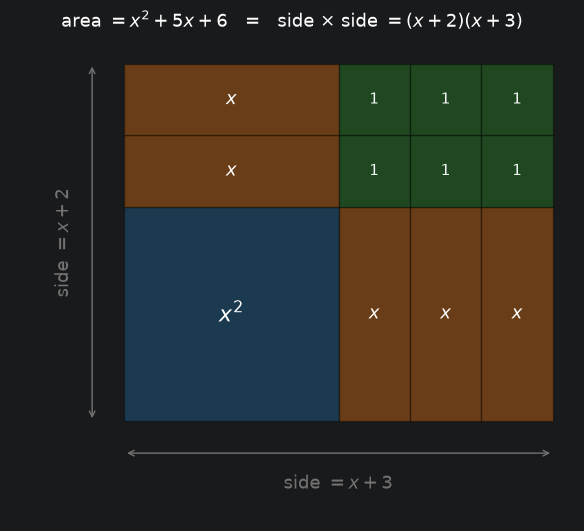

In [1]:
# --- picture: factoring x^2 + 5x + 6 = (x+2)(x+3) as a rectangle ---

import numpy as np                  # np = the fast-numbers tool (arrays, powers, roots)
import matplotlib.pyplot as plt     # plt = matplotlib's drawing tool
from matplotlib.patches import Rectangle   # Rectangle = a filled box we can draw

# Colour code used in the WHOLE notebook, so every picture speaks the same language:
C_MAIN  = "#1f77b4"   # blue   -> the x^2 part / the main object
C_ALT   = "#d62728"   # red    -> a warning, a root, or something wrong
C_FILL  = "#2ca02c"   # green  -> the answer / the constant part
C_STRIP = "#ff7f0e"   # orange -> the middle (the "x" strips)
C_GREY  = "0.45"      # mid grey -> helper lines; readable on light and dark screens

X = 3.0    # we DRAW x as if it were 3 units long, just so the picture has a size

fig, ax = plt.subplots(figsize=(6.2, 5.4))

# 1) the x-by-x square  -> this is the x^2 term
ax.add_patch(Rectangle((0, 0), X, X, facecolor=C_MAIN, alpha=0.35, edgecolor="black"))
ax.text(X/2, X/2, r"$x^2$", ha="center", va="center", fontsize=16)

# 2) three x-by-1 strips on the right -> 3x
for i in range(3):
    ax.add_patch(Rectangle((X + i, 0), 1, X, facecolor=C_STRIP, alpha=0.35, edgecolor="black"))
    ax.text(X + i + 0.5, X/2, r"$x$", ha="center", va="center", fontsize=13)

# 3) two x-by-1 strips on top -> 2x   (3x + 2x = 5x, the middle term)
for j in range(2):
    ax.add_patch(Rectangle((0, X + j), X, 1, facecolor=C_STRIP, alpha=0.35, edgecolor="black"))
    ax.text(X/2, X + j + 0.5, r"$x$", ha="center", va="center", fontsize=13)

# 4) the 3-by-2 block of unit squares in the corner -> 6
for i in range(3):
    for j in range(2):
        ax.add_patch(Rectangle((X + i, X + j), 1, 1, facecolor=C_FILL, alpha=0.35, edgecolor="black"))
        ax.text(X + i + 0.5, X + j + 0.5, "1", ha="center", va="center", fontsize=11)

# 5) label the two SIDES of the whole rectangle -> these are the factors
ax.annotate("", xy=(0, -0.45), xytext=(X + 3, -0.45),
            arrowprops=dict(arrowstyle="<->", color=C_GREY))          # bottom arrow
ax.text((X + 3)/2, -0.95, r"side $= x+3$", ha="center", fontsize=13, color=C_GREY)

ax.annotate("", xy=(-0.45, 0), xytext=(-0.45, X + 2),
            arrowprops=dict(arrowstyle="<->", color=C_GREY))          # left arrow
ax.text(-0.85, (X + 2)/2, r"side $= x+2$", ha="center", va="center",
        rotation=90, fontsize=13, color=C_GREY)

ax.set_xlim(-1.6, X + 3.3)
ax.set_ylim(-1.4, X + 2.4)
ax.set_aspect("equal")          # a square must LOOK square, so shape is not distorted
ax.axis("off")                  # no axes here: this is a picture, not a graph
ax.set_title(r"area $= x^2+5x+6$   =   side $\times$ side $= (x+2)(x+3)$", fontsize=13)
plt.tight_layout()
plt.show()


### 1.3 Why the factored form is the useful form

Look at the same polynomial written two ways:

$$p(x) = x^{2}+5x+6 \qquad\text{and}\qquad p(x) = (x+2)(x+3).$$

They are the **same function** — same value for every $x$ (notebook 04, Theorem 9 then says
the coefficient lists must match too). But they *tell you different things at a glance*:

| Question | Expanded form | Factored form |
| --- | --- | --- |
| What is $p(10)$? | easy: $100+50+6=156$ | easy: $12\times 13 = 156$ |
| Where is $p(x)=0$? | you must work | **you can read it**: $x=-2,\,-3$ |
| Where is $p$ positive / negative? | you must work | **you can read it** (sign of each part) |
| Is $p$ divisible by $x+2$? | you must divide | **you can read it**: yes |

So: expanded form is for *computing*, factored form is for *understanding*. A big part of
algebra is choosing the right form for the question you are asking.

The next picture shows this. The graph crosses the horizontal axis exactly at the numbers
that make a factor zero. **Each factor gives a root, and each root gives a factor.** That
is the factor theorem from notebook 04, and it is the single most useful fact in this
notebook.


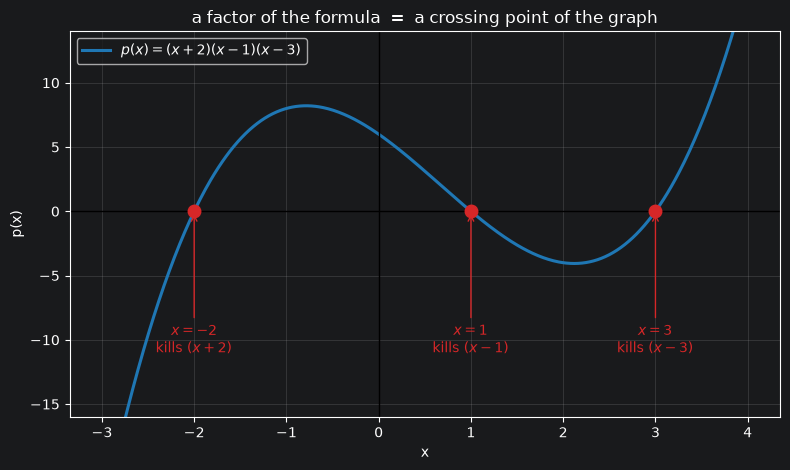

In [2]:
# --- picture: each factor of p is a place where the graph touches zero ---

# We plot p(x) = (x+2)(x-1)(x-3), which expands to x^3 - 2x^2 - 5x + 6.
x = np.linspace(-3.0, 4.0, 500)      # 500 evenly spaced x-values from -3 to 4
p = (x + 2) * (x - 1) * (x - 3)      # the polynomial, written in FACTORED form

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.plot(x, p, color=C_MAIN, linewidth=2.2, label=r"$p(x)=(x+2)(x-1)(x-3)$")
ax.axhline(0, color="black", linewidth=1)     # the horizontal axis y = 0
ax.axvline(0, color="black", linewidth=1)     # the vertical axis x = 0

# mark the three roots: the x-values that make ONE of the brackets equal to zero
roots = [-2, 1, 3]
labels = ["$x=-2$\nkills $(x+2)$",
          "$x=1$\nkills $(x-1)$",
          "$x=3$\nkills $(x-3)$"]
for r, lab in zip(roots, labels):
    ax.plot(r, 0, "o", color=C_ALT, markersize=9, zorder=5)   # a red dot on the axis
    ax.annotate(lab, xy=(r, 0), xytext=(r, -11),              # text under the dot
                ha="center", fontsize=10, color=C_ALT,
                arrowprops=dict(arrowstyle="->", color=C_ALT))

ax.set_ylim(-16, 14)
ax.set_xlabel("x")
ax.set_ylabel("p(x)")
ax.set_title("a factor of the formula  =  a crossing point of the graph")
ax.legend(loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### 1.4 How far do we go? "Completely factored"

If I ask you to factor $12$, the answer $12 = 2\times 6$ is *true* but not *finished*: the
$6$ can still be broken. The finished answer is $12 = 2\times 2\times 3$, where nothing can
be broken any more. Numbers that cannot be broken are called **prime**.

Polynomials work the same way. $x^{4}-16$ can be broken:

$$x^{4}-16 = (x^{2}-4)(x^{2}+4) = (x-2)(x+2)(x^{2}+4).$$

Now stop. $(x^{2}+4)$ cannot be broken any further using real numbers — we will *prove*
that later (Theorem 8). A polynomial that cannot be broken is called **irreducible**
("cannot be reduced"). Irreducible polynomials are the primes of the polynomial world.

But there is a catch that has no equal in the world of numbers, and you must learn it now:

> **"Can it be factored?" has no answer until you say *which numbers you are allowed to
> use*.**

Look:

| Polynomial | using only fractions ($\mathbb{Q}$) | using all real numbers ($\mathbb{R}$) |
| --- | --- | --- |
| $x^{2}-4$ | $(x-2)(x+2)$ | $(x-2)(x+2)$ |
| $x^{2}-2$ | **cannot** | $(x-\sqrt2)(x+\sqrt2)$ |
| $x^{2}+1$ | **cannot** | **cannot** |

$x^{2}-2$ is irreducible over the fractions but *not* over the reals, because $\sqrt2$ is
irrational — which we proved in notebook 01, Theorem E. So the same polynomial changes its
answer depending on the number system. Always say which system you are in.

In this notebook, **the default is: factor over the integers** (whole numbers), because
that is what "factor this" means in a normal exercise. When we want something else, we will
say so out loud.


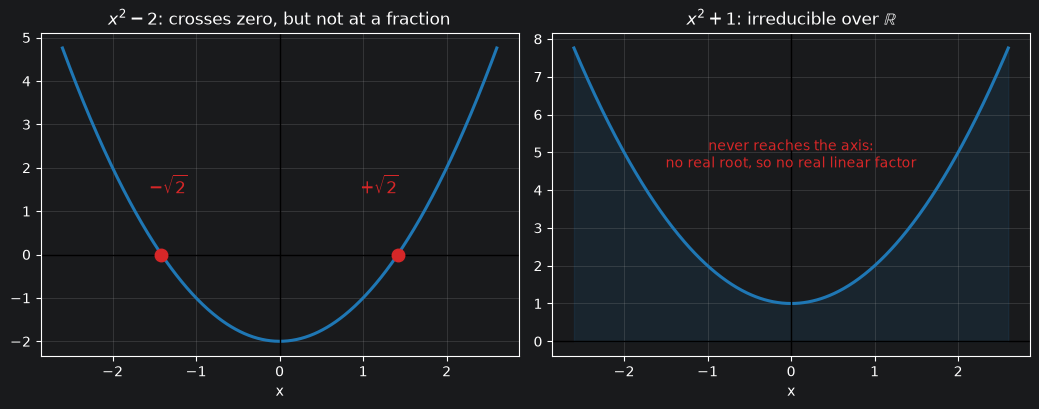

In [3]:
# --- picture: the number system decides whether a factorisation exists ---

x = np.linspace(-2.6, 2.6, 500)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

# LEFT: x^2 - 2  -> it DOES cross zero, at the two irrational points +/- sqrt(2)
axes[0].plot(x, x**2 - 2, color=C_MAIN, linewidth=2.2)
axes[0].axhline(0, color="black", linewidth=1)
s = np.sqrt(2)                                   # np.sqrt = square root
axes[0].plot([-s, s], [0, 0], "o", color=C_ALT, markersize=9)
axes[0].annotate(r"$-\sqrt{2}$", xy=(-s, 0), xytext=(-s - 0.15, 1.4), color=C_ALT, fontsize=12)
axes[0].annotate(r"$+\sqrt{2}$", xy=(s, 0), xytext=(s - 0.45, 1.4), color=C_ALT, fontsize=12)
axes[0].set_title(r"$x^2-2$: crosses zero, but not at a fraction")

# RIGHT: x^2 + 1 -> it NEVER touches zero, so no real linear factor exists
axes[1].plot(x, x**2 + 1, color=C_MAIN, linewidth=2.2)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].fill_between(x, 0, x**2 + 1, color=C_MAIN, alpha=0.12)   # shade the gap
axes[1].text(0, 4.6, "never reaches the axis:\nno real root, so no real linear factor",
             ha="center", fontsize=10, color=C_ALT)
axes[1].set_title(r"$x^2+1$: irreducible over $\mathbb{R}$")

for a in axes:
    a.axvline(0, color="black", linewidth=1)
    a.set_xlabel("x")
    a.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### 1.5 The plan of this notebook

Factoring by hand is not one trick. It is a short **checklist**, always used in the same
order. Here it is; the rest of the notebook explains and proves each line.

1. **GCF first, always.** Pull out anything that every term shares.
2. **Count the terms.**
   * 2 terms → look for difference of squares, difference of cubes, sum of cubes.
   * 3 terms → look for a perfect square, then try the trinomial methods.
   * 4 terms → try **grouping**.
3. **Higher degree, no pattern?** → use the **rational root theorem** to find a root, then
   divide it out (notebook 04, Theorem 5), and repeat on what is left.
4. **Check each piece again.** A factor you produced may still be factorable.
5. **Multiply back** to check. This step is not optional; it costs 30 seconds and catches
   almost every mistake.


---

## 2. Formal definitions

From now on, **polynomial** means what it meant in notebook 04: an expression
$a_nx^n+\dots+a_1x+a_0$ built with $+$, $-$, $\times$ only. We write $\deg p$ for the
**degree** of $p$ (the highest power with a non-zero coefficient).

A short piece of notation first. When we say *"a polynomial over $\mathbb{Z}$"* we mean
*"all its coefficients are integers"*. Same for $\mathbb{Q}$ (fractions) and $\mathbb{R}$
(all real numbers). The set of these polynomials has a standard name:

$$\mathbb{Z}[x], \qquad \mathbb{Q}[x], \qquad \mathbb{R}[x].$$

Read $\mathbb{R}[x]$ out loud as *"R adjoin x"* or simply *"polynomials with real
coefficients"*. The square brackets are just part of the name.

---

**Definition 1 (divides / factor).** Let $f$ and $g$ be polynomials with $g \neq 0$. We say
$g$ **divides** $f$, written $g \mid f$, if there is a polynomial $q$ with

$$f = g\,q .$$

Then $g$ is called a **factor** of $f$, and so is $q$.

*(This is Definition 10 of notebook 04, repeated because everything here depends on it.
Note the word "polynomial": $q$ must be a polynomial. $x \mid 1$ is **false**, because
$1/x$ is not a polynomial. You will prove this properly in Exercise 19 of notebook 04.)*

---

**Definition 2 (factorisation).** A **factorisation** of $f$ is any way of writing

$$f = g_1 g_2 \cdots g_k$$

as a product of polynomials.

---

**Definition 3 (unit; trivial factorisation).** A **unit** is a non-zero constant
polynomial, for example $5$, $-1$, or $\tfrac23$. Units are the "boring" factors: you can
always write

$$x^2+5x+6 \;=\; 5 \cdot \left(\tfrac15 x^2 + x + \tfrac65\right),$$

and that tells you nothing. A factorisation is called **trivial** if one of the factors is
a unit.

*Why are non-zero constants special?* Because a constant $c \neq 0$ divides **every**
polynomial: $f = c\cdot(\tfrac1c f)$, and $\tfrac1c f$ is still a polynomial. So constants
are useless as factors, in the same way that $1$ and $-1$ are useless as factors of a whole
number.

---

**Definition 4 (irreducible).** A polynomial $p$ is **irreducible over $F$** (where $F$ is
$\mathbb{Q}$ or $\mathbb{R}$) if

1. $\deg p \ge 1$ (so it is not a constant), and
2. it is impossible to write $p = gh$ with $g,h$ polynomials over $F$ and
   $\deg g \ge 1$ and $\deg h \ge 1$.

Otherwise ($\deg p \ge 1$ and such a splitting exists) $p$ is called **reducible**.

*In words:* irreducible means *"the only way to write it as a product is the boring way,
with a constant"*. Irreducible polynomials are the **primes** of polynomial arithmetic.

*Warning already given in §1.4, repeated because it is the most common misunderstanding:
irreducibility depends on $F$. $x^2-2$ is irreducible over $\mathbb{Q}$ and reducible over
$\mathbb{R}$.*

---

**Definition 5 (completely factored).** $f$ is **completely factored over $F$** when it is
written as

$$f = c\, p_1 p_2 \cdots p_m$$

where $c$ is a constant and every $p_i$ is irreducible over $F$.

*This is the finish line.* "Factor completely" in an exercise means: keep going until every
bracket is irreducible.

---

**Definition 6 (greatest common factor of the terms; content).** Given a polynomial with
integer coefficients, the **GCF** (greatest common factor, sometimes written GCD) of its
terms is the largest monomial that divides every term. It has two parts:

* the **number part**: $\gcd$ of all the coefficients;
* the **letter part**: the *lowest* power of $x$ that appears in any term.

Example: for $12x^5 - 18x^3 + 30x^2$, the number part is $\gcd(12,18,30)=6$ and the letter
part is $x^{2}$ (the lowest power present). So the GCF is $6x^{2}$ and

$$12x^5-18x^3+30x^2 = 6x^2\left(2x^3-3x+5\right).$$

*(Reminder: $\gcd(a,b)$, the **greatest common divisor**, is the biggest whole number that
divides both $a$ and $b$. $\gcd(12,18)=6$.)*

---

**Definition 7 (monic).** A polynomial is **monic** if its leading coefficient is $1$:
$x^3-4x+1$ is monic, $2x^3-4x+1$ is not.

Monic polynomials are the easiest to work with, and later (the unique factorisation theorem, Theorem 16) we use them to get a
*unique* answer, because otherwise you can always shuffle constants between the factors:
$2x^2-2 = 2(x-1)(x+1) = (2x-2)(x+1) = (x-1)(2x+2)$ are all the "same" factorisation.

---

**Definition 8 (multiplicity of a root).** If $r$ is a root of $f$, the **multiplicity** of
$r$ is the largest $m \ge 1$ such that

$$(x-r)^m \mid f .$$

A root of multiplicity $1$ is called **simple**; multiplicity $2$ is a **double root**, and
so on.

Example: in $f(x) = (x-1)^2(x+2)$, the root $1$ has multiplicity $2$ and the root $-2$ has
multiplicity $1$. We will see that the graph *crosses* the axis at a simple root but only
*touches and turns back* at a double root.

---

**Definition 9 (quadratic in form).** An expression is **quadratic in form** if a
substitution $u = (\text{something})$ turns it into a quadratic $au^2+bu+c$.

Example: $x^4-5x^2+4$ becomes $u^2-5u+4$ with $u = x^2$. This is a *change of variable*,
one of the most powerful moves in all of mathematics: do not solve the hard problem, rename
it into an easy one.


---

## 3. Theorems, with full proofs

### 3.1 The reason we factor at all

**Theorem 1 (zero-product property for polynomials).**
Let $f = g_1g_2\cdots g_k$ be a factorisation, and let $r$ be a real number. Then

$$f(r) = 0 \quad\Longleftrightarrow\quad g_i(r) = 0 \text{ for at least one } i .$$

**Proof.**
Evaluating a product at $x=r$ gives the product of the values — this is exactly what
Definition 8 of notebook 04 (the product of polynomials) says, together with the fact that
substitution respects $+$ and $\times$. So

$$f(r) = g_1(r)\,g_2(r)\cdots g_k(r),$$

which is now a product of **real numbers**.

($\Leftarrow$) If some $g_i(r)=0$, then the product of the numbers contains a $0$, and by
Theorem A of notebook 01 ($a\cdot 0 = 0$) the whole product is $0$. So $f(r)=0$.

($\Rightarrow$) Suppose $f(r)=0$, so the product of the $k$ numbers is $0$. Notebook 01,
Theorem B says: if $ab=0$ then $a=0$ or $b=0$. Apply it to
$g_1(r)\cdot\big(g_2(r)\cdots g_k(r)\big)$: either $g_1(r)=0$ — and we are done — or the
remaining product is $0$, and we repeat the same step on it. After at most $k-1$ repeats we
must land on a single factor equal to zero. (Formally this is induction on $k$; the base
case $k=1$ is trivial.) $\blacksquare$

> **This theorem is the whole point of the notebook.** It is why "solve $f(x)=0$" turns
> into "factor $f$, then set each bracket to zero".

**Warning that costs many marks:** Theorem 1 is about **zero**, and nothing else. From
$(x+2)(x+3) = 6$ you may **not** conclude $x+2=6$ or $x+3=6$. There is no such rule,
because $6 = 1\times 6 = 2\times 3 = 12\times\tfrac12 = \dots$ has endlessly many
splittings, while $0$ has the special property of Theorem B. Always move everything to one
side first, so that the right-hand side is exactly $0$.

---

### 3.2 Tool 1 — pull out the common factor

**Theorem 2 (GCF extraction).** Let $f = t_1+t_2+\dots+t_n$ be a sum of terms and suppose a
polynomial $d \ne 0$ divides every term: $t_i = d\,q_i$. Then

$$f = d\,(q_1+q_2+\dots+q_n),$$

and the second factor is uniquely determined by $d$ and $f$.

**Proof.**
*Existence.* Substitute $t_i = d q_i$ and use the distributive law (axiom of $\mathbb{R}$,
notebook 01) backwards, $n-1$ times:

$$f = dq_1 + dq_2 + \dots + dq_n = d\,(q_1+\dots+q_n).$$

*Uniqueness.* Suppose $f = d\,u = d\,v$ for polynomials $u,v$. Then $d(u-v)=0$. Now use
the degree rule of notebook 04, Theorem 2: if $u-v \ne 0$ then
$\deg\big(d(u-v)\big) = \deg d + \deg(u-v)$, which is a real degree, so $d(u-v)$ is not the
zero polynomial — a contradiction. Hence $u-v=0$, i.e. $u=v$. $\blacksquare$

*(The uniqueness half is why "divide each term by the GCF" is a legal, well-defined move
and not a guess.)*

**How to use it.** Take the GCF from Definition 6 as your $d$: the $\gcd$ of the
coefficients times the lowest power of $x$. Then $q_i = t_i / d$ for each term.

**The trap.** When the leading term is negative, pull out the minus sign too:

$$-x^2+5x-6 = -\left(x^2-5x+6\right) = -(x-2)(x-3).$$

If you skip that, you will spend five minutes trying to factor $-x^2+5x-6$ directly and get
confused by the signs.

---

### 3.3 Tool 2 — grouping

**Theorem 3 (factoring by grouping).** For any polynomials $a,b,u,v$:

$$au + av + bu + bv = (a+b)(u+v).$$

**Proof.** Expand the right side with the distributive law:

$$(a+b)(u+v) = a(u+v) + b(u+v) = au+av+bu+bv. \qquad \blacksquare$$

That looks too easy to be a theorem. Its power is that we read it **right to left**. When
you see four terms, try to split them into two pairs so that each pair has a common factor,
and so that the *same* bracket appears twice:

$$\underbrace{x^3+3x^2}_{\text{pair 1}} + \underbrace{2x+6}_{\text{pair 2}}
 = x^2(x+3) + 2(x+3) = (x^2+2)(x+3).$$

The moment "$(x+3)$" appears twice, Theorem 2 finishes the job with $d = x+3$.

**When does it fail?** If the two brackets come out different, the pairing was wrong. Try
another pairing (there are three ways to split four terms into two pairs) before giving up.

---

### 3.4 Tool 3 — the special products, read backwards

In notebook 04 we proved seven special products by expanding. Every one of them is a
factoring rule if you read it from right to left. Here are the ones that matter, restated
as a theorem.

**Theorem 4 (the factoring identities).** For all real numbers (or polynomials) $a,b$:

| # | identity | name |
| --- | --- | --- |
| (i) | $a^2-b^2 = (a-b)(a+b)$ | difference of squares |
| (ii) | $a^2+2ab+b^2 = (a+b)^2$ | perfect square (plus) |
| (iii) | $a^2-2ab+b^2 = (a-b)^2$ | perfect square (minus) |
| (iv) | $a^3-b^3 = (a-b)(a^2+ab+b^2)$ | difference of cubes |
| (v) | $a^3+b^3 = (a+b)(a^2-ab+b^2)$ | sum of cubes |
| (vi) | $a^n-b^n = (a-b)(a^{n-1}+a^{n-2}b+\dots+ab^{n-2}+b^{n-1})$ | general |

**Proof.** Each one is proved the same way: expand the right-hand side and watch the middle
terms cancel.

(i) $(a-b)(a+b) = a^2+ab-ba-b^2 = a^2-b^2$, because $ab = ba$ (commutativity) so the two
middle terms cancel.

(ii) $(a+b)^2 = (a+b)(a+b) = a^2+ab+ba+b^2 = a^2+2ab+b^2$.

(iii) same with $-b$ in place of $b$: $(a-b)^2 = a^2+2a(-b)+(-b)^2 = a^2-2ab+b^2$, using
$(-b)^2=b^2$ (notebook 01, Theorem C).

(iv) Expand:
$$(a-b)(a^2+ab+b^2) = \underbrace{a^3+a^2b+ab^2}_{a\cdot(\dots)} \;-\; \underbrace{a^2b+ab^2+b^3}_{b\cdot(\dots)} = a^3-b^3,$$
since $a^2b$ cancels with $a^2b$ and $ab^2$ cancels with $ab^2$.

(v) Put $-b$ in place of $b$ in (iv):
$a^3-(-b)^3 = (a-(-b))\big(a^2+a(-b)+(-b)^2\big)$. Now $(-b)^3 = -b^3$ and $(-b)^2=b^2$, so
this reads $a^3+b^3 = (a+b)(a^2-ab+b^2)$. **We did not need a new proof — we reused (iv).**

(vi) This is Theorem 4 of notebook 04, proved there by *telescoping*: in the product
$(a-b)\sum_{k=0}^{n-1}a^{n-1-k}b^{k}$ every middle term appears once with $+$ and once with
$-$, so everything cancels except $a^n$ and $-b^n$. Note (i) is the case $n=2$ and (iv) is
the case $n=3$. $\blacksquare$

**How to remember the signs of (iv) and (v) — but only after you can prove them.**
The English mnemonic is **SOAP**:

* **S**ame — the sign inside the *short* bracket is the same as the sign in the question;
* **O**pposite — the sign of the middle term in the *long* bracket is the opposite;
* **A**lways **P**ositive — the last sign in the long bracket is always $+$.

$$a^3 \;\underset{\textbf{S}}{\mathbf{-}}\; b^3 = (a \;\underset{\textbf{S}}{\mathbf{-}}\; b)(a^2 \;\underset{\textbf{O}}{\mathbf{+}}\; ab \;\underset{\textbf{AP}}{\mathbf{+}}\; b^2).$$

**There is no "sum of squares" line in the table.** $a^2+b^2$ does not factor over the real
numbers. That is not laziness; we prove it in Theorem 8.

---

### 3.5 Tool 4 — trinomials

**Theorem 5 (monic trinomial).** Let $b,c$ be numbers. Then

$$x^2+bx+c = (x+p)(x+q) \quad\Longleftrightarrow\quad p+q=b \ \text{ and } \ pq=c .$$

**Proof.**
($\Leftarrow$) Expand: $(x+p)(x+q) = x^2+qx+px+pq = x^2+(p+q)x+pq$. If $p+q=b$ and $pq=c$
this is exactly $x^2+bx+c$.

($\Rightarrow$) Suppose the two polynomials are equal. By the **identity theorem**
(notebook 04, Theorem 9), two polynomials that are equal as functions have equal
coefficient lists. Comparing the coefficient of $x$ gives $p+q=b$; comparing the constant
term gives $pq=c$. $\blacksquare$

> Notice how much work notebook 04 is doing here. "Compare the coefficients" is not a habit
> or a hope — it is a **theorem**, and this proof would have a hole in it without one.

**How to use it.** To factor $x^2+bx+c$ over the integers, list the integer pairs whose
**product** is $c$, and pick the pair whose **sum** is $b$. Start from the product, not the
sum: a number has only a few divisors, but endlessly many pairs adding to $b$.

Sign guide (all of it follows from $pq=c$, $p+q=b$):

| sign of $c$ | sign of $b$ | then $p,q$ are |
| --- | --- | --- |
| $+$ | $+$ | both positive |
| $+$ | $-$ | both negative |
| $-$ | any | opposite signs; the bigger one has the sign of $b$ |

**Theorem 6 (the "$ac$" method for $ax^2+bx+c$).** Let $a \ne 0$ and suppose there are
numbers $m,n$ with

$$m+n = b \qquad\text{and}\qquad mn = ac .$$

Then

$$a\left(ax^2+bx+c\right) = (ax+m)(ax+n).$$

**Proof.** Expand the right-hand side:

$$(ax+m)(ax+n) = a^2x^2 + anx + amx + mn = a^2x^2 + a(m+n)x + mn .$$

Now substitute the two assumptions $m+n=b$ and $mn=ac$:

$$= a^2x^2 + abx + ac = a\left(ax^2+bx+c\right). \qquad \blacksquare$$

**How to use it.** Multiply $a$ by $c$, find two numbers with product $ac$ and sum $b$,
split the middle term into those two pieces, and then use **grouping** (Theorem 3):

$$6x^2+11x+3: \quad ac = 18,\; b = 11 \;\Rightarrow\; m=9,\ n=2,$$
$$6x^2+9x+2x+3 = 3x(2x+3)+1(2x+3) = (3x+1)(2x+3).$$

*Why does the grouping always work?* Because Theorem 6 says the product
$(ax+m)(ax+n)$ equals $a$ times our trinomial, so a factor of $a$ must be hiding inside
$(ax+m)(ax+n)$ and can be divided out — which is exactly what the grouping step does for
you, without fractions.

---

### 3.6 When nothing factors nicely: complete the square

**Theorem 7 (completing the square).** For $a \ne 0$,

$$ax^2+bx+c \;=\; a\left(x+\frac{b}{2a}\right)^{2} + \frac{4ac-b^{2}}{4a} .$$

**Proof.** Start from the right and expand, using identity (ii) of Theorem 4:

$$a\left(x+\frac{b}{2a}\right)^{2} = a\left(x^2 + 2\cdot x\cdot\frac{b}{2a} + \frac{b^2}{4a^2}\right)
= ax^2 + bx + \frac{b^2}{4a}.$$

Add the last term:

$$ax^2+bx+\frac{b^{2}}{4a} + \frac{4ac-b^{2}}{4a} = ax^2+bx+\frac{4ac}{4a} = ax^2+bx+c. \qquad\blacksquare$$

The quantity

$$\boxed{\;D = b^2-4ac\;}$$

is called the **discriminant** (a word meaning "the thing that tells them apart"). With it
the theorem reads

$$ax^2+bx+c = a\left[\left(x+\frac{b}{2a}\right)^{2} - \frac{D}{4a^{2}}\right].$$

Everything about a quadratic is decided by the sign of $D$, as the next theorem shows.

**Theorem 8 (exactly when a real quadratic factors).** Let $a\ne0$ and $D=b^2-4ac$. Then
$ax^2+bx+c$ is **reducible over $\mathbb{R}$** if and only if $D \ge 0$. In that case

$$ax^2+bx+c = a\left(x - \frac{-b+\sqrt{D}}{2a}\right)\left(x - \frac{-b-\sqrt{D}}{2a}\right).$$

If $D<0$ the quadratic is **irreducible over $\mathbb{R}$**.

**Proof.**
*Case $D \ge 0$.* Then $\sqrt D$ exists as a real number (notebook 02, Theorem 7). Write
$u = x + \frac{b}{2a}$. Theorem 7 gives

$$ax^2+bx+c = a\left[u^2 - \left(\frac{\sqrt D}{2a}\right)^{2}\right],$$

and by the difference of squares (Theorem 4(i)) this is

$$a\left(u - \frac{\sqrt D}{2a}\right)\left(u + \frac{\sqrt D}{2a}\right)
= a\left(x + \frac{b-\sqrt D}{2a}\right)\left(x + \frac{b+\sqrt D}{2a}\right),$$

which is the stated formula. Both brackets have degree $1$, so the quadratic is reducible.

*Case $D < 0$.* Then $-D>0$, and by Theorem 7

$$ax^2+bx+c = a\left[\underbrace{\left(x+\frac{b}{2a}\right)^{2}}_{\ \ge\, 0} + \underbrace{\frac{-D}{4a^{2}}}_{>\,0}\right].$$

The bracket is a non-negative number plus a strictly positive number, so it is **never
zero**, for any real $x$. Multiplying by $a \ne 0$ keeps it non-zero. So the quadratic has
**no real root**.

Now suppose, for contradiction, that it were reducible: $ax^2+bx+c = gh$ with
$\deg g,\deg h \ge 1$. By the degree rule (notebook 04, Theorem 2),
$\deg g + \deg h = 2$, so $\deg g = \deg h = 1$. A degree-one real polynomial
$g = \alpha x+\beta$ with $\alpha \ne 0$ has the root $x = -\beta/\alpha$, a real number.
By Theorem 1 that number is also a root of the quadratic — contradicting "no real root".
Hence it is irreducible. $\blacksquare$

**Two corollaries you should say out loud.**

* $x^2+1$ has $D = 0-4 = -4 < 0$, so **$x^2+1$ is irreducible over $\mathbb{R}$**. More
  generally $a^2+b^2$ never factors. (Over the complex numbers it does — that is topic
  "Complex Numbers" later in the syllabus.)
* The long bracket in the sum of cubes, $a^2-ab+b^2$, seen as a quadratic in $a$, has
  $D = (-b)^2-4b^2 = -3b^2 < 0$ whenever $b\ne0$. So that bracket is irreducible too, and
  $(a+b)(a^2-ab+b^2)$ is already the complete factorisation over $\mathbb{R}$.


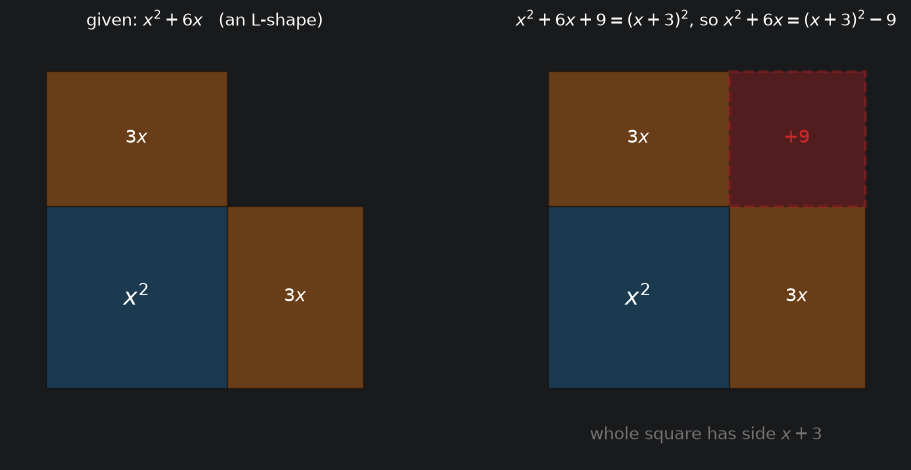

In [4]:
# --- picture: completing the square is literally completing a square ---

# We show x^2 + 6x = (x+3)^2 - 9.
# Start with a square of side x, and two rectangles 3-by-x glued on. To make the shape a
# perfect square of side (x+3), a 3-by-3 corner is missing. So we ADD 9 and then SUBTRACT 9.

X = 4.0   # again, a drawing size for "x"
H = 3.0   # half of the 6, i.e. b/2

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))

# LEFT picture: what we are given, x^2 + 6x
ax = axes[0]
ax.add_patch(Rectangle((0, 0), X, X, facecolor=C_MAIN, alpha=0.35, edgecolor="black"))
ax.text(X/2, X/2, r"$x^2$", ha="center", va="center", fontsize=17)
ax.add_patch(Rectangle((X, 0), H, X, facecolor=C_STRIP, alpha=0.35, edgecolor="black"))
ax.text(X + H/2, X/2, r"$3x$", ha="center", va="center", fontsize=13)
ax.add_patch(Rectangle((0, X), X, H, facecolor=C_STRIP, alpha=0.35, edgecolor="black"))
ax.text(X/2, X + H/2, r"$3x$", ha="center", va="center", fontsize=13)
ax.set_title(r"given: $x^2+6x$   (an L-shape)")

# RIGHT picture: the same shape plus the missing 3-by-3 corner
ax = axes[1]
ax.add_patch(Rectangle((0, 0), X, X, facecolor=C_MAIN, alpha=0.35, edgecolor="black"))
ax.text(X/2, X/2, r"$x^2$", ha="center", va="center", fontsize=17)
ax.add_patch(Rectangle((X, 0), H, X, facecolor=C_STRIP, alpha=0.35, edgecolor="black"))
ax.text(X + H/2, X/2, r"$3x$", ha="center", va="center", fontsize=13)
ax.add_patch(Rectangle((0, X), X, H, facecolor=C_STRIP, alpha=0.35, edgecolor="black"))
ax.text(X/2, X + H/2, r"$3x$", ha="center", va="center", fontsize=13)
# the missing corner, drawn with a dashed red edge because we ADD it artificially
ax.add_patch(Rectangle((X, X), H, H, facecolor=C_ALT, alpha=0.30,
                       edgecolor=C_ALT, linestyle="--", linewidth=2))
ax.text(X + H/2, X + H/2, r"$+9$", ha="center", va="center", fontsize=13, color=C_ALT)
ax.text(X/2 + H/2, -1.15, r"whole square has side $x+3$", ha="center", fontsize=12, color=C_GREY)
ax.set_title(r"$x^2+6x+9=(x+3)^2$, so $x^2+6x=(x+3)^2-9$")

for ax in axes:
    ax.set_xlim(-0.8, X + H + 0.8)
    ax.set_ylim(-1.6, X + H + 0.8)
    ax.set_aspect("equal")    # squares must look square
    ax.axis("off")
plt.tight_layout()
plt.show()


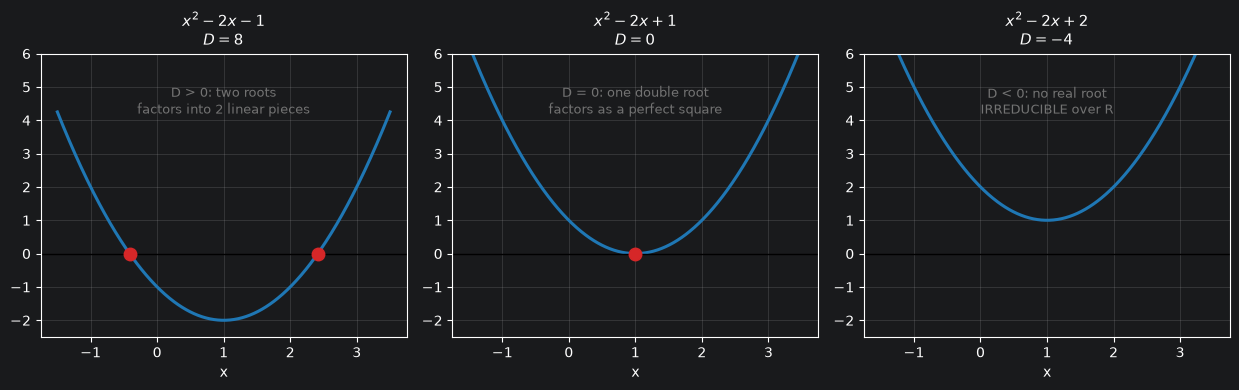

In [5]:
# --- picture: the discriminant D decides everything ---

x = np.linspace(-1.5, 3.5, 500)

# three quadratics with the same shape but different D:
quads = [
    (1.0, -2.0, -1.0, r"$x^2-2x-1$"),   # D = 4+4 = 8 > 0  -> two real roots
    (1.0, -2.0,  1.0, r"$x^2-2x+1$"),   # D = 4-4 = 0      -> one double root
    (1.0, -2.0,  2.0, r"$x^2-2x+2$"),   # D = 4-8 = -4 < 0 -> no real root
]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))

for ax, (a, b, c, name) in zip(axes, quads):
    D = b**2 - 4*a*c                      # the discriminant
    y = a*x**2 + b*x + c
    ax.plot(x, y, color=C_MAIN, linewidth=2.2)
    ax.axhline(0, color="black", linewidth=1)

    if D > 0:                             # two different real roots
        r1 = (-b + np.sqrt(D)) / (2*a)
        r2 = (-b - np.sqrt(D)) / (2*a)
        ax.plot([r1, r2], [0, 0], "o", color=C_ALT, markersize=9)
        verdict = "D > 0: two roots\nfactors into 2 linear pieces"
    elif D == 0:                          # one root, counted twice
        r1 = -b / (2*a)
        ax.plot([r1], [0], "o", color=C_ALT, markersize=9)
        verdict = "D = 0: one double root\nfactors as a perfect square"
    else:                                 # no real root at all
        verdict = "D < 0: no real root\nIRREDUCIBLE over R"

    ax.set_title(name + f"\n$D={D:.0f}$", fontsize=11)
    ax.text(1.0, 4.2, verdict, ha="center", fontsize=9.5, color=C_GREY)
    ax.set_ylim(-2.5, 6.0)
    ax.grid(alpha=0.25)
    ax.set_xlabel("x")

plt.tight_layout()
plt.show()


---

### 3.7 Tool 5 — find a root, peel it off, repeat

The four tools above are pattern-matching. They work when the polynomial happens to look
like something we recognise. For a general cubic such as $2x^3-3x^2-11x+6$ there is no
pattern to see. We need a real method.

The method has two halves. This section is the first half; §3.8 is the second.

**Theorem 9 (peeling roots).** Let $f$ have degree $n\ge1$ and let $r$ be a root of $f$
(that is, $f(r)=0$). Then

$$f = (x-r)\,q, \qquad \deg q = n-1,$$

and $q$ is found by dividing $f$ by $x-r$. Repeating this as long as a root exists gives

$$f = (x-r_1)(x-r_2)\cdots(x-r_k)\;g,$$

where $g$ has **no real root** and $\deg g = n-k$.

**Proof.**
The first sentence is the **factor theorem** (notebook 04, Theorem 7): $f(r)=0$ if and only
if $(x-r) \mid f$. So $f=(x-r)q$ for some polynomial $q$. Taking degrees and using
$\deg(pq)=\deg p+\deg q$ (notebook 04, Theorem 2),

$$n = \deg f = \deg(x-r) + \deg q = 1 + \deg q, \quad\text{so}\quad \deg q = n-1 .$$

Now repeat on $q$. Each step lowers the degree by exactly $1$, so after at most $n$ steps we
must stop; and we stop only when the polynomial that is left has no real root. Calling the
leftover $g$ and multiplying the pieces back together gives the displayed formula.
$\blacksquare$

**Remarks worth stopping for.**

* This *re-proves* notebook 04, Theorem 8 ("degree $n$ means at most $n$ real roots") in
  one line: you cannot peel more than $n$ linear factors off a degree-$n$ polynomial,
  because the degree would go negative.
* $g$ may be a constant (then $f$ split completely into linear factors), or it may be a
  genuine polynomial with no real root such as $x^2+1$.
* The theorem is useless until we can **find** a root $r$. That is the missing half.

---

### 3.8 Where do the roots come from? The rational root theorem

We cannot find *all* real roots by hand — most of them are irrational and have no formula.
But we can find every **rational** root (every root that is a fraction), exactly, with a
finite search. That is enough for almost every exercise, because exercises are built to
have nice roots.

The result rests on a fact about whole numbers that is worth learning for its own sake.

#### 3.8.1 Two facts about integers

**Fact (division with remainder).** For integers $a$ and $d>0$ there are integers $k,r$ with

$$a = dk + r, \qquad 0 \le r < d .$$

*Proof.* Look at the set $S=\{\,a-dk \;:\; k\in\mathbb{Z},\ a-dk\ge0\,\}$. It is not empty
(take $k$ very negative). By the **well-ordering principle** — every non-empty set of
non-negative integers has a smallest element, which is the twin of the induction principle
from notebook 02 — let $r$ be its smallest element, say $r=a-dk$. If $r \ge d$ then
$r-d = a-d(k+1) \ge 0$ would be a smaller element of $S$, which is impossible. So
$0\le r<d$. $\square$

**Lemma 10 (Bezout's identity).** Let $a,b$ be integers, not both zero, and let
$d=\gcd(a,b)$. Then there are integers $u,v$ with

$$au+bv = d .$$

In particular, if $\gcd(a,b)=1$ there are integers with $au+bv=1$.

*(Read the name as "bay-ZOO". Etienne Bezout was an 18th-century French mathematician.)*

**Proof.**
Consider the set of all **positive** numbers you can build as a combination:

$$S=\{\,ax+by \;:\; x,y\in\mathbb{Z}\,\}\cap\{\text{positive integers}\}.$$

$S$ is not empty: $a\cdot a + b\cdot b = a^2+b^2 > 0$ since $a,b$ are not both zero. By
well-ordering, $S$ has a smallest element; call it $e$, and write $e=au+bv$.

*Step 1: $e$ divides $a$.* Divide with remainder: $a = ek + r$ with $0\le r<e$. Then

$$r = a - ek = a - k(au+bv) = a(1-ku) + b(-kv),$$

so $r$ is itself a combination of $a$ and $b$. If $r>0$, then $r\in S$ and $r<e$,
contradicting that $e$ is the smallest. So $r=0$, i.e. $e \mid a$. The same argument with
$b$ gives $e \mid b$. So $e$ is a **common divisor** of $a$ and $b$.

*Step 2: $e$ is the greatest one.* Let $c$ be any common divisor of $a$ and $b$, say
$a=c a'$ and $b=c b'$. Then

$$e = au+bv = c(a'u+b'v),$$

so $c \mid e$, and therefore $c \le |e| = e$. Hence $e = \gcd(a,b) = d$, and
$d = au+bv$. $\blacksquare$

> **Why this is beautiful.** The gcd is defined by a *search* ("the biggest number dividing
> both"), but Bezout says it can also be *built* by one addition. That change of viewpoint —
> from searching to building — is the engine of the next two proofs.

**Lemma 11 (a power keeps coprimality).** If $\gcd(p,q)=1$ then $\gcd(p^n,q)=1$ for every
$n \ge 1$.

**Proof.** By Lemma 10 there are integers $u,v$ with $pu+qv=1$. Raise both sides to the
power $n$:

$$1 = 1^{\,n} = (pu+qv)^{n} = \sum_{k=0}^{n}\binom{n}{k}(pu)^{n-k}(qv)^{k},$$

by the **binomial theorem** (notebook 04, Theorem 11). Look at the sum. The term with $k=0$
is $(pu)^n = p^n u^n$. **Every other term** ($k\ge1$) contains at least one factor $q$. So
we can write

$$1 = p^{n}\,u^{n} + q\,M \qquad\text{for some integer } M .$$

Now let $c$ be any common divisor of $p^n$ and $q$. It divides the right-hand side, so
$c \mid 1$, so $c = \pm1$. Hence $\gcd(p^n,q)=1$. $\blacksquare$

*(Notice that the binomial theorem, which looked like a curiosity in notebook 04, is doing
real work here.)*

#### 3.8.2 The theorem itself

**Theorem 12 (rational root theorem).** Let

$$f(x)=a_nx^n+a_{n-1}x^{n-1}+\dots+a_1x+a_0$$

have **integer** coefficients, with $a_n\ne0$ and $a_0\ne0$. Suppose the fraction
$\dfrac{p}{q}$ is a root of $f$, written in **lowest terms** (that is, $p,q$ are integers,
$q\ge1$, and $\gcd(p,q)=1$). Then

$$p \mid a_0 \qquad\text{and}\qquad q \mid a_n .$$

**In words:** *the top of the fraction divides the constant term, and the bottom divides the
leading coefficient.* So there are only finitely many candidates, and you can test them all.

**Proof.**
Start from $f(p/q)=0$:

$$a_n\frac{p^n}{q^n}+a_{n-1}\frac{p^{n-1}}{q^{n-1}}+\dots+a_1\frac{p}{q}+a_0 = 0 .$$

Multiply everything by $q^n$ to clear the fractions. Every term becomes a whole number:

$$a_np^n + a_{n-1}p^{n-1}q + a_{n-2}p^{n-2}q^{2} + \dots + a_1pq^{n-1} + a_0q^{n} = 0. \tag{$\ast$}$$

**Part 1: $p \mid a_0$.** In $(\ast)$, move the last term to the other side:

$$a_0q^{n} = -\left(a_np^n + a_{n-1}p^{n-1}q + \dots + a_1pq^{n-1}\right).$$

Every term in the bracket contains at least one $p$, so we may pull $p$ out:

$$a_0q^{n} = p\cdot\underbrace{\left(-a_np^{n-1} - a_{n-1}p^{n-2}q - \dots - a_1q^{n-1}\right)}_{\text{an integer}} .$$

So $p \mid a_0q^n$. By Lemma 11, $\gcd(p,q^n)=1$, so Bezout gives integers with
$pu+q^nv=1$. Multiply that by $a_0$:

$$a_0 = a_0pu + a_0q^{n}v .$$

The first term has a factor $p$; the second term has the factor $a_0q^n$, which we just
showed is a multiple of $p$. So $p$ divides the whole right-hand side, i.e. $p \mid a_0$.

**Part 2: $q \mid a_n$.** Same trick from the other end. Move the *first* term of $(\ast)$
across:

$$a_np^{n} = -\left(a_{n-1}p^{n-1}q + \dots + a_1pq^{n-1} + a_0q^{n}\right) = q\cdot(\text{an integer}),$$

because every term in that bracket contains at least one $q$. So $q \mid a_np^n$. By
Lemma 11 (with the roles swapped, $\gcd(q,p^n)=1$) and Bezout, $qu'+p^nv'=1$, so

$$a_n = a_nqu' + a_np^{n}v',$$

and $q$ divides both terms. Hence $q \mid a_n$. $\blacksquare$

**Corollary 13 (monic case).** If $f$ has integer coefficients **and is monic**
($a_n=1$), then every rational root of $f$ is an **integer**, and it divides $a_0$.

**Proof.** By Theorem 12, $q \mid a_n = 1$, so $q=1$ (we chose $q\ge1$). Then the root is
$p/1=p$, an integer, and $p \mid a_0$. $\blacksquare$

> Corollary 13 is a machine for proving irrationality. $\sqrt[3]{2}$ is a root of
> $x^3-2$, which is monic with $a_0=-2$. If $\sqrt[3]{2}$ were rational it would have to be
> an integer dividing $2$: one of $\pm1,\pm2$. But $1^3=1$, $2^3=8$, and the negatives are
> negative — none of them is $2$. So $\sqrt[3]{2}$ is irrational. You will write this out in
> Exercise 19.

**How to use Theorem 12 in practice** (this is the general factoring algorithm):

1. Make the coefficients integers (multiply through, or pull out the GCF).
2. List all divisors of $a_0$ and all divisors of $a_n$.
3. The candidate roots are $\pm\dfrac{\text{divisor of }a_0}{\text{divisor of }a_n}$.
4. Test them (Horner's method from notebook 04 is the fast way).
5. When one works, peel it off with Theorem 9 and repeat on the smaller polynomial.
6. When you reach degree $2$, use Theorem 8 (the discriminant) and stop.

**Honesty note.** The theorem finds only *rational* roots. If $f$ has none — like
$x^3-2$, or $x^2+1$ — the search returns nothing, and that is a real answer, not a failure:
it proves the polynomial has no linear factor over $\mathbb{Q}$.


candidates: ['-6', '-3', '-2', '-3/2', '-1', '-1/2', '1/2', '1', '3/2', '2', '3', '6']
actual roots among them: ['-2', '1/2', '3']


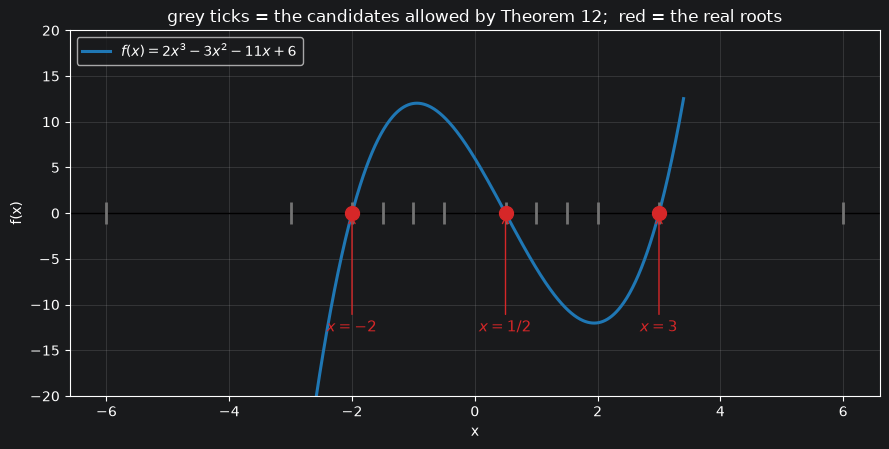

In [6]:
# --- picture: the rational root theorem shrinks an infinite search to a small list ---

# f(x) = 2x^3 - 3x^2 - 11x + 6.  a_0 = 6, a_n = 2.
# divisors of 6: 1,2,3,6      divisors of 2: 1,2
# candidates: +/- {1,2,3,6}/{1,2}
from fractions import Fraction     # Fraction = exact fractions, no rounding at all

def divisors(n):
    """All positive whole numbers that divide n."""
    n = abs(n)
    return [d for d in range(1, n + 1) if n % d == 0]

a0, an = 6, 2
cands = sorted({Fraction(s * p, q)                 # a set {} removes duplicates like 2/2 = 1
                for p in divisors(a0)
                for q in divisors(an)
                for s in (1, -1)})

def f(t):
    return 2*t**3 - 3*t**2 - 11*t + 6

hits = [c for c in cands if f(c) == 0]             # exact test, no floating point
print("candidates:", [str(c) for c in cands])
print("actual roots among them:", [str(c) for c in hits])

# --- now draw it ---
x = np.linspace(-2.6, 3.4, 500)
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(x, 2*x**3 - 3*x**2 - 11*x + 6, color=C_MAIN, linewidth=2.2,
        label=r"$f(x)=2x^3-3x^2-11x+6$")
ax.axhline(0, color="black", linewidth=1)

# grey ticks: every candidate the theorem allows
for c in cands:
    ax.plot(float(c), 0, "|", color=C_GREY, markersize=16, markeredgewidth=2)

# red dots: the candidates that really are roots
for c in hits:
    ax.plot(float(c), 0, "o", color=C_ALT, markersize=10, zorder=5)
    ax.annotate(f"$x={c}$", xy=(float(c), 0), xytext=(float(c), -13),
                ha="center", color=C_ALT, fontsize=11,
                arrowprops=dict(arrowstyle="->", color=C_ALT))

ax.set_title("grey ticks = the candidates allowed by Theorem 12;  red = the real roots")
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.set_ylim(-20, 20)
ax.legend(loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


---

### 3.9 The summit: polynomials *are* whole numbers in disguise

This section is the hardest in the notebook. Read it slowly, twice. Nothing later depends
on it, but it is the idea that makes all of the above feel inevitable instead of random.

Put the two worlds side by side:

| whole numbers $\mathbb{Z}$ | polynomials $\mathbb{Q}[x]$ |
| --- | --- |
| size $\lvert a\rvert$ | degree $\deg f$ |
| units: $1, -1$ | units: the non-zero constants |
| division with remainder: $a=dk+r$, $0\le r<\lvert d\rvert$ | division algorithm: $f=gq+r$, $r=0$ or $\deg r<\deg g$ (nb 04, Thm 5) |
| primes: $2,3,5,7,\dots$ | irreducibles: $x-1$, $x^2+1$, $\dots$ |
| $12 = 2\cdot2\cdot3$, and in only one way | ? |

The question mark is the last row. Does a polynomial factor into irreducibles in only one
way? The answer is yes, and — this is the point — **the proof is the same proof**, with
"degree" written wherever "size" used to be.

**Lemma 14 (Bezout for polynomials).** Let $f,g$ be polynomials over $\mathbb{Q}$ (or over
$\mathbb{R}$), not both zero. Then among all polynomials of the form $fu+gv$ (with $u,v$
polynomials) there is one, call it $d$, of smallest degree, and this $d$ divides both $f$
and $g$.

**Proof.** Let $S$ be the set of **non-zero** polynomials of the form $fu+gv$. It is not
empty ($f\cdot1+g\cdot0=f$, or $g$ if $f=0$). Degrees are non-negative integers, so by
well-ordering there is an element $d=fu_0+gv_0$ of smallest degree.

Divide $f$ by $d$ using the division algorithm (notebook 04, Theorem 5):

$$f = dq + r, \qquad r=0 \ \text{ or } \ \deg r < \deg d .$$

Then

$$r = f - dq = f - (fu_0+gv_0)q = f(1-u_0q) + g(-v_0q),$$

so $r$ has the form $fu+gv$ too. If $r\ne0$ then $r\in S$ with $\deg r<\deg d$ —
impossible. So $r=0$ and $d \mid f$. The same argument gives $d \mid g$. $\blacksquare$

**Lemma 15 (Euclid's lemma for polynomials).** Let $P$ be irreducible and suppose
$P \mid fg$. Then $P \mid f$ or $P \mid g$.

**Proof.** Suppose $P \nmid f$; we must show $P \mid g$.

Apply Lemma 14 to $P$ and $f$: there is $d = Pu_0+fv_0$ of smallest degree dividing both.
Since $d \mid P$ and $P$ is irreducible, $d$ is either a non-zero constant or a constant
times $P$ (those are the only divisors an irreducible has, by Definition 4). It cannot be a
constant times $P$, because $d \mid f$ would then give $P \mid f$, which we assumed is
false. So $d = c$, a non-zero constant. Dividing by $c$:

$$1 = P\,\frac{u_0}{c} + f\,\frac{v_0}{c} \;=\; P\,U + f\,V .$$

Multiply both sides by $g$:

$$g = P\,Ug + (fg)\,V .$$

$P$ divides the first term (obviously) and the second term (because $P \mid fg$ by
assumption). So $P$ divides their sum, which is $g$. $\blacksquare$

> Compare this with the proof of Theorem 12. It is the same move both times: **Bezout turns
> "these two share no factor" into an equation $=1$, and then you multiply that equation by
> whatever you want to divide.** Learn that move; it appears everywhere in mathematics.

**Theorem 16 (unique factorisation for polynomials).** Every polynomial $f$ with
$\deg f\ge1$ can be written as

$$f = c\,P_1P_2\cdots P_m$$

with $c$ a non-zero constant and each $P_i$ irreducible and **monic**. Moreover this is the
only such way, apart from the order in which you write the $P_i$.

**Proof.**
*Existence*, by strong induction on $\deg f$.
If $\deg f = 1$, then $f = a x + b = a\left(x+\frac{b}{a}\right)$, and $x+\frac ba$ is monic
of degree 1, hence irreducible (it cannot split into two factors of degree $\ge1$, since
degrees would add to more than 1). Done.
Now let $\deg f = n$ and assume the claim for every degree below $n$. Either $f$ is
irreducible — then divide by its leading coefficient $a$ and write $f = a\cdot(f/a)$, done —
or $f=gh$ with $1\le\deg g,\deg h<n$. By the induction hypothesis both $g$ and $h$ are
constants times products of monic irreducibles; multiply the two results together and
collect the two constants into one. Done.

*Uniqueness.* Suppose

$$c\,P_1\cdots P_m = c'\,Q_1\cdots Q_k$$

with all $P_i,Q_j$ monic irreducible. Comparing leading coefficients: the leading
coefficient of a product of monic polynomials is $1$, so the left side has leading
coefficient $c$ and the right side $c'$, giving $c=c'$ and therefore
$P_1\cdots P_m=Q_1\cdots Q_k$.

Now induct on $m$. $P_1$ divides the right-hand side, so by Lemma 15 (used $k-1$ times)
$P_1 \mid Q_j$ for some $j$. But $Q_j$ is irreducible, so its only divisors are constants
and constant multiples of itself; since $\deg P_1 \ge 1$ we get $P_1 = \lambda Q_j$, and
since both are monic, $\lambda=1$ and $P_1=Q_j$. Cancel $P_1$ from both sides — legal by the
uniqueness half of Theorem 2 — and repeat with $P_2$. After $m$ steps the left side is $1$,
so the right side must be $1$ too, forcing $k=m$. $\blacksquare$

**What this buys you.** "Factor completely" has **one** right answer. If you factor
$x^4-16$ by first seeing a difference of squares, and your friend factors it some other way,
you must both end up with $(x-2)(x+2)(x^2+4)$. That is not luck. It is Theorem 16.


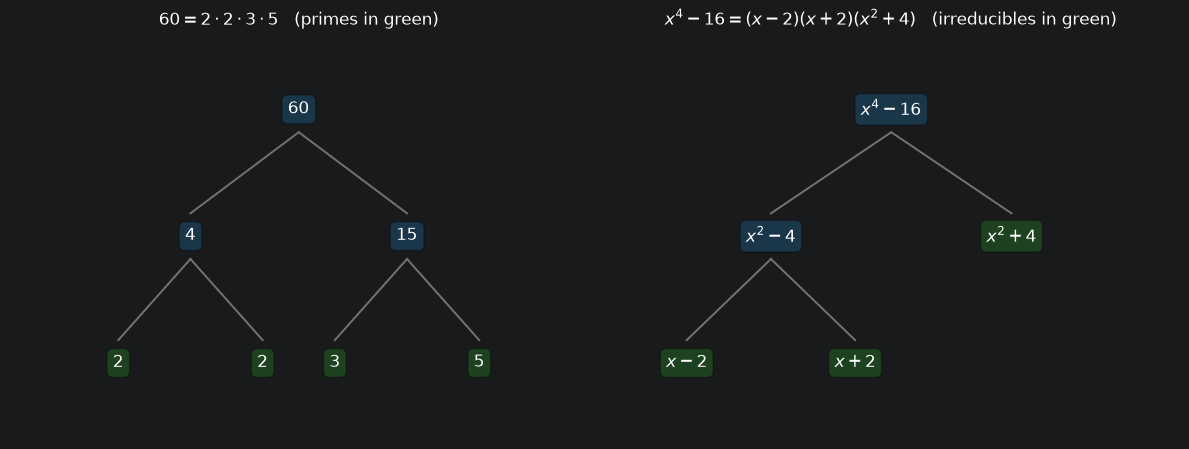

In [7]:
# --- picture: the same factor tree, twice: for a number and for a polynomial ---

def draw_tree(ax, nodes, edges, title):
    """nodes: dict name -> (x, y, text).  edges: list of (parent, child)."""
    for a, b in edges:                                  # draw the lines first, so boxes sit on top
        xa, ya, _ = nodes[a]
        xb, yb, _ = nodes[b]
        ax.plot([xa, xb], [ya - 0.18, yb + 0.18], color=C_GREY, linewidth=1.4, zorder=1)
    for name, (x0, y0, txt) in nodes.items():
        leaf = name.startswith("L")                     # names starting with L are the final pieces
        ax.text(x0, y0, txt, ha="center", va="center", fontsize=12, zorder=2,
                bbox=dict(boxstyle="round,pad=0.35",
                          facecolor=(C_FILL if leaf else C_MAIN), alpha=0.30,
                          edgecolor="black"))
    ax.set_title(title, fontsize=12)
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# left: the number 60
nodes = {"A": (0.0, 2.0, "$60$"),
         "B": (-0.9, 1.0, "$4$"), "C": (0.9, 1.0, "$15$"),
         "L1": (-1.5, 0.0, "$2$"), "L2": (-0.3, 0.0, "$2$"),
         "L3": (0.3, 0.0, "$3$"), "L4": (1.5, 0.0, "$5$")}
edges = [("A", "B"), ("A", "C"), ("B", "L1"), ("B", "L2"), ("C", "L3"), ("C", "L4")]
draw_tree(axes[0], nodes, edges, r"$60 = 2\cdot 2\cdot 3\cdot 5$   (primes in green)")

# right: the polynomial x^4 - 16
nodes = {"A": (0.0, 2.0, "$x^4-16$"),
         "B": (-1.0, 1.0, "$x^2-4$"), "L3": (1.0, 1.0, "$x^2+4$"),
         "L1": (-1.7, 0.0, "$x-2$"), "L2": (-0.3, 0.0, "$x+2$")}
edges = [("A", "B"), ("A", "L3"), ("B", "L1"), ("B", "L2")]
draw_tree(axes[1], nodes, edges,
          r"$x^4-16=(x-2)(x+2)(x^2+4)$   (irreducibles in green)")

for ax in axes:
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-0.6, 2.6)
plt.tight_layout()
plt.show()


---

### 3.10 Summary table: which tool, and what it rests on

| Tool | Theorem | Rests on |
| --- | --- | --- |
| Why factoring solves equations | Thm 1 | nb 01 Thm A, B |
| Pull out the GCF | Thm 2 | distributive axiom; nb 04 Thm 2 (degrees) |
| Grouping (4 terms) | Thm 3 | distributive axiom |
| $a^2-b^2$, $a^3\pm b^3$, $a^n-b^n$ | Thm 4 | nb 04 Thm 3, Thm 4 |
| $x^2+bx+c$ | Thm 5 | nb 04 Thm 9 (identity theorem) |
| $ax^2+bx+c$ ("$ac$" method) | Thm 6 | Thm 3 |
| Completing the square | Thm 7 | Thm 4(ii) |
| Is a quadratic irreducible? | Thm 8 | Thm 7; nb 02 Thm 7 ($\sqrt{\ }$ exists); nb 04 Thm 2 |
| Peel a known root off | Thm 9 | nb 04 Thm 7 (factor theorem), Thm 5 (division) |
| Find the rational roots | Thm 12 | Lemma 10 (Bezout), Lemma 11, nb 04 Thm 11 (binomial) |
| Rational root of a monic $\Rightarrow$ integer | Cor 13 | Thm 12 |
| There is only one right answer | Thm 16 | Lemma 14, 15; nb 04 Thm 5 |


---

## 4. Traps — the nine mistakes almost everyone makes

**Trap 1 — forgetting the GCF.** Always look for a common factor *first*.

$$3x^3-27x \;\ne\; \text{(some clever trick)}; \qquad 3x^3-27x = 3x(x^2-9) = 3x(x-3)(x+3).$$

If you dive straight at $x^2-9$ inside your head you will lose the $3x$.

**Trap 2 — using the zero-product rule when the right side is not zero.**
From $(x+1)(x-3)=5$ you may **not** write $x+1=5$. Expand, move everything to one side,
then factor. (See the warning under Theorem 1.)

**Trap 3 — "a sum of squares must factor somehow".** It does not, over $\mathbb{R}$:

$$x^2+9 \quad\text{is irreducible (Theorem 8: } D = 0-36 <0).$$

Do **not** write $(x+3)^2$ — expand that and you get $x^2+6x+9$, a different polynomial.

**Trap 4 — stopping too early.** "Factor completely" means completely.

$$x^4-1 = (x^2-1)(x^2+1) \quad\text{is NOT finished}; \qquad x^4-1 = (x-1)(x+1)(x^2+1) \ \text{is}.$$

After every step, look at each bracket again.

**Trap 5 — cancelling a term instead of a factor.** This is the biggest trap of the *next*
notebook, and it starts here. You may cancel a **factor** of the whole top and bottom:

$$\frac{(x-1)(x+3)}{(x-1)} = x+3 \quad (x \ne 1) \qquad\text{correct.}$$

You may **never** cancel a piece of a sum:

$$\frac{x^2-1}{x-1} \ne \frac{x^2}{x} \qquad\text{WRONG.}$$

Factor first, cancel second. Never the other way round.

**Trap 6 — the sign of the factor.** If $r$ is a root, the factor is $(x-r)$, with a minus.
Root $-2$ gives the factor $\big(x-(-2)\big) = (x+2)$. Every year, thousands of students
write $(x-2)$ here. Check by substituting.

**Trap 7 — "no real root" does not mean "irreducible".** For degree $\le3$ it does (a degree
$\le3$ polynomial with no root cannot split, since one piece would have degree 1). For
degree $4$ it is false:

$$x^4+4 = (x^2-2x+2)(x^2+2x+2),$$

and $x^4+4>0$ always, so it has no real root at all. You will prove this in Exercise 20.

**Trap 8 — counting roots without multiplicity.** $f(x)=(x-1)^2(x+2)$ has degree 3 but only
**two** different roots. At the double root the graph touches the axis and turns back
instead of crossing. The picture below shows the difference; keep it in your head.

**Trap 9 — confusing factoring with solving.** "Factor $x^2-5x+6$" has the answer
$(x-2)(x-3)$. "Solve $x^2-5x+6=0$" has the answer $x=2$ or $x=3$. They are different
questions with different answers. Read the instruction.


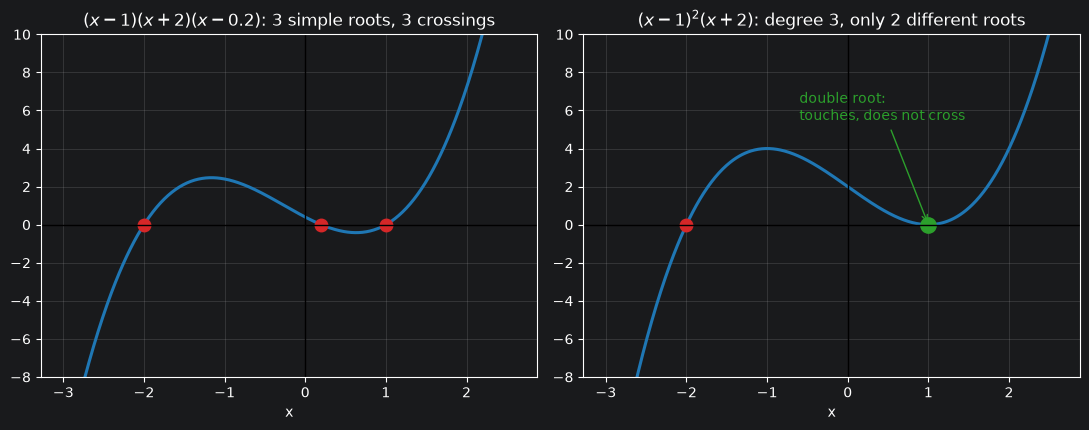

In [8]:
# --- picture: a simple root CROSSES, a double root TOUCHES ---

x = np.linspace(-3.0, 2.6, 600)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

# LEFT: three different (simple) roots -> the curve crosses the axis three times
y1 = (x - 1) * (x + 2) * (x - 0.2)
axes[0].plot(x, y1, color=C_MAIN, linewidth=2.2)
axes[0].plot([1, -2, 0.2], [0, 0, 0], "o", color=C_ALT, markersize=9)
axes[0].set_title(r"$(x-1)(x+2)(x-0.2)$: 3 simple roots, 3 crossings")

# RIGHT: a double root at x = 1 -> the curve TOUCHES the axis and turns back
y2 = (x - 1)**2 * (x + 2)
axes[1].plot(x, y2, color=C_MAIN, linewidth=2.2)
axes[1].plot([-2], [0], "o", color=C_ALT, markersize=9)
axes[1].plot([1], [0], "o", color=C_FILL, markersize=11)
axes[1].annotate("double root:\ntouches, does not cross",
                 xy=(1, 0), xytext=(-0.6, 5.5), fontsize=10, color=C_FILL,
                 arrowprops=dict(arrowstyle="->", color=C_FILL))
axes[1].set_title(r"$(x-1)^2(x+2)$: degree 3, only 2 different roots")

for ax in axes:
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_ylim(-8, 10)
    ax.set_xlabel("x")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


---

## 5. Worked examples

Every example follows the checklist of §1.5, and every one ends with the **multiply-back
check**. Do not skip that check when you work on your own.

---

### Example 1 — GCF, including the minus sign

Factor $\;-12x^4y + 18x^3y^2 - 30x^2y$.

*Step 1: the number part.* $\gcd(12,18,30)=6$. The first term is negative, so we pull out
$-6$ to leave a positive leading coefficient — that makes everything after this easier.

*Step 2: the letter part.* The lowest power of $x$ present is $x^2$; the lowest power of
$y$ present is $y^1$. So the letter part is $x^2y$.

*Step 3:* the GCF is $-6x^2y$. Divide each term by it:

$$\frac{-12x^4y}{-6x^2y}=2x^2, \qquad \frac{18x^3y^2}{-6x^2y}=-3xy, \qquad \frac{-30x^2y}{-6x^2y}=5 .$$

$$\boxed{-12x^4y+18x^3y^2-30x^2y = -6x^2y\left(2x^2-3xy+5\right)}$$

*Check:* $-6x^2y\cdot 2x^2 = -12x^4y$ ✓, $-6x^2y\cdot(-3xy) = 18x^3y^2$ ✓,
$-6x^2y\cdot5 = -30x^2y$ ✓.

*Is $2x^2-3xy+5$ factorable? No obvious pair works, so we stop.*

---

### Example 2 — grouping (four terms)

Factor $\;2x^3 - x^2 + 6x - 3$.

Four terms → try grouping (Theorem 3). Split into the first two and the last two:

$$\underbrace{2x^3-x^2}_{=\,x^2(2x-1)} \;+\; \underbrace{6x-3}_{=\,3(2x-1)} \;=\; x^2(2x-1)+3(2x-1).$$

The bracket $(2x-1)$ appears twice. Pull it out (Theorem 2 with $d=2x-1$):

$$\boxed{2x^3-x^2+6x-3 = (2x-1)(x^2+3)}$$

*Check:* $(2x-1)(x^2+3) = 2x^3+6x-x^2-3$ ✓.

*Finished?* $2x-1$ has degree 1, so it is irreducible. $x^2+3$ has $D = 0-12<0$, so by
Theorem 8 it is irreducible over $\mathbb{R}$. Yes, finished.

---

### Example 3 — difference of squares, applied twice

Factor $\;x^4-81$.

$x^4=(x^2)^2$ and $81=9^2$, so Theorem 4(i) with $a=x^2$, $b=9$:

$$x^4-81 = (x^2-9)(x^2+9).$$

**Do not stop** (Trap 4). Look at each bracket:

* $x^2-9=(x-3)(x+3)$, another difference of squares;
* $x^2+9$ has $D=-36<0$: irreducible.

$$\boxed{x^4-81=(x-3)(x+3)(x^2+9)}$$

*Check:* $(x-3)(x+3)=x^2-9$, and $(x^2-9)(x^2+9)=x^4-81$ ✓.

---

### Example 4 — a monic trinomial

Factor $\;x^2-x-20$.

By Theorem 5 we need $p,q$ with $pq=-20$ and $p+q=-1$. Start from the **product**, and list
the integer pairs:

| $p\cdot q=-20$ | $p+q$ |
| --- | --- |
| $1,\,-20$ | $-19$ |
| $2,\,-10$ | $-8$ |
| $4,\,-5$ | $\mathbf{-1}$ ✔ |
| $5,\,-4$ | $+1$ |

$$\boxed{x^2-x-20=(x+4)(x-5)}$$

*Check:* $(x+4)(x-5)=x^2-5x+4x-20=x^2-x-20$ ✓.

---

### Example 5 — a non-monic trinomial, by the "$ac$" method

Factor $\;6x^2-7x-20$.

Here $a=6$, $b=-7$, $c=-20$, so $ac=-120$. We need two numbers with product $-120$ and sum
$-7$: they are $-15$ and $+8$ (since $-15\cdot8=-120$ and $-15+8=-7$).

Split the middle term into those two pieces, then group (Theorem 6, then Theorem 3):

$$6x^2 \underbrace{-15x+8x}_{=\,-7x} -20 = 3x(2x-5) + 4(2x-5) = (3x+4)(2x-5).$$

$$\boxed{6x^2-7x-20=(3x+4)(2x-5)}$$

*Check:* $(3x+4)(2x-5)=6x^2-15x+8x-20=6x^2-7x-20$ ✓.

*Why did the grouping work?* Theorem 6 guarantees it: with $m=-15,n=8$ we have
$6\,(6x^2-7x-20)=(6x-15)(6x+8)=3(2x-5)\cdot2(3x+4)=6(2x-5)(3x+4)$, and dividing by $6$
gives the answer.

---

### Example 6 — perfect square, and a near miss

(a) Factor $\;9x^2-24x+16$.

Guess it is a perfect square. The outer terms are $(3x)^2$ and $(-4)^2$. Theorem 4(iii)
says the middle term must then be $2\cdot(3x)\cdot(-4) = -24x$. It is. So

$$\boxed{9x^2-24x+16=(3x-4)^2}$$

(b) Factor $\;9x^2-25x+16$.

The outer terms are the same, but $2\cdot(3x)\cdot(-4)=-24x \ne -25x$. **Not** a perfect
square. Try the $ac$ method: $ac=144$, and we need a sum of $-25$: $-9$ and $-16$ give
$144$ and $-25$ ✓.

$$9x^2-9x-16x+16 = 9x(x-1)-16(x-1) = (9x-16)(x-1).$$

$$\boxed{9x^2-25x+16=(9x-16)(x-1)}$$

*The lesson: check the middle term before you believe a perfect square.*

---

### Example 7 — cubes (with a GCF hiding in front)

Factor $\;54x^3-16$.

**GCF first** (Trap 1): $\gcd(54,16)=2$, so $54x^3-16=2(27x^3-8)$.

Now $27x^3=(3x)^3$ and $8=2^3$, so use the difference of cubes, Theorem 4(iv), with
$a=3x$, $b=2$:

$$27x^3-8 = (3x-2)\big((3x)^2+(3x)(2)+2^2\big) = (3x-2)(9x^2+6x+4).$$

$$\boxed{54x^3-16 = 2(3x-2)(9x^2+6x+4)}$$

*Is the long bracket factorable?* $D = 6^2-4\cdot9\cdot4 = 36-144 = -108 < 0$, so no
(Theorem 8). Finished.

*Check:* $(3x-2)(9x^2+6x+4)=27x^3+18x^2+12x-18x^2-12x-8=27x^3-8$ ✓.

---

### Example 8 — the general algorithm: a cubic with no visible pattern

Factor $\;f(x)=2x^3-3x^2-11x+6$ completely.

*Step 1: GCF?* $\gcd(2,3,11,6)=1$ and there is a constant term, so nothing to pull out.

*Step 2: pattern?* Four terms — try grouping: $x^2(2x-3) - (11x-6)$. The brackets do not
match. The other pairings fail too. No pattern.

*Step 3: rational root theorem (Theorem 12).* Here $a_0=6$ and $a_n=2$.

* divisors of $6$: $1,2,3,6$;
* divisors of $2$: $1,2$;
* candidates: $\pm1,\pm2,\pm3,\pm6,\pm\tfrac12,\pm\tfrac32$.

Test them (Horner is fastest). $f(1)=2-3-11+6=-6\ne0$. $f(-1)=-2-3+11+6=12\ne0$.
$f(2)=16-12-22+6=-12\ne0$. $f(3)=54-27-33+6=0$ ✔

*Step 4: peel it off (Theorem 9).* Divide $f$ by $(x-3)$ using long division from
notebook 04:

$$2x^3-3x^2-11x+6 = (x-3)\left(2x^2+3x-2\right).$$

*Step 5: repeat on the quotient.* $2x^2+3x-2$ is a quadratic, so use the $ac$ method:
$ac=-4$, sum $=3$ → the numbers $4$ and $-1$:

$$2x^2+4x-x-2 = 2x(x+2)-1(x+2) = (2x-1)(x+2).$$

$$\boxed{2x^3-3x^2-11x+6=(x-3)(2x-1)(x+2)}$$

*Check by multiplying back:* $(2x-1)(x+2)=2x^2+3x-2$; then
$(x-3)(2x^2+3x-2)=2x^3+3x^2-2x-6x^2-9x+6=2x^3-3x^2-11x+6$ ✓.

*Fast check:* put $x=1$ in both forms. Left: $2-3-11+6=-6$. Right:
$(1-3)(2-1)(1+2)=(-2)(1)(3)=-6$ ✓. (This "$x=1$ trick" from notebook 04 catches most
arithmetic slips in two seconds.)

---

### Example 9 — quadratic in form (a change of variable)

Factor $\;x^4-5x^2+4$.

This is not a quadratic — it has degree 4. But **only even powers of $x$ appear**. Set
$u=x^2$ (Definition 9). Then

$$x^4-5x^2+4 = u^2-5u+4 = (u-1)(u-4)$$

by Theorem 5 (product $4$, sum $-5$ → the numbers $-1,-4$). Now substitute back $u=x^2$ and
keep going:

$$(x^2-1)(x^2-4) = (x-1)(x+1)(x-2)(x+2).$$

$$\boxed{x^4-5x^2+4=(x-1)(x+1)(x-2)(x+2)}$$

Degree 4, and four different real roots: $\pm1,\pm2$. The picture below shows all four
crossings.


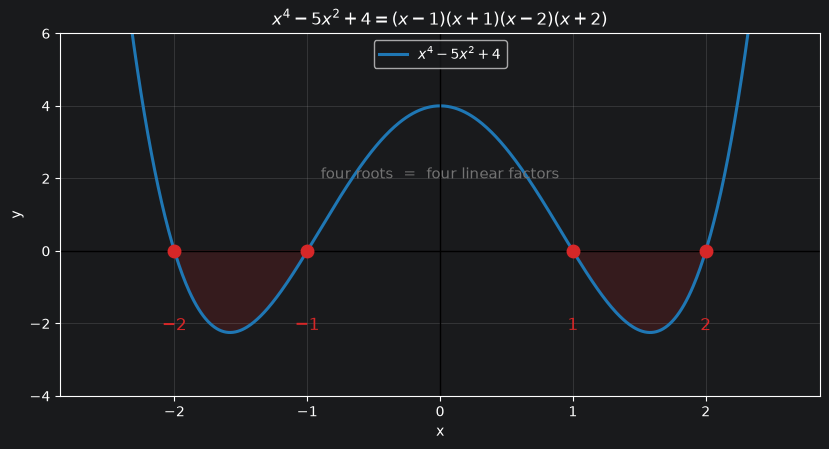

In [9]:
# --- picture: x^4 - 5x^2 + 4 has all four of its roots visible ---

x = np.linspace(-2.6, 2.6, 600)
y = x**4 - 5*x**2 + 4

fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.plot(x, y, color=C_MAIN, linewidth=2.2, label=r"$x^4-5x^2+4$")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)

for r in (-2, -1, 1, 2):
    ax.plot(r, 0, "o", color=C_ALT, markersize=9, zorder=5)
    ax.annotate(f"${r}$", xy=(r, 0), xytext=(r, -2.2), ha="center",
                color=C_ALT, fontsize=12)

# shade where the polynomial is negative: exactly between the "inner" and "outer" roots
ax.fill_between(x, y, 0, where=(y < 0), color=C_ALT, alpha=0.15)
ax.text(0, 2.0, "four roots  =  four linear factors", ha="center", fontsize=11, color=C_GREY)

ax.set_ylim(-4, 6)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(r"$x^4-5x^2+4=(x-1)(x+1)(x-2)(x+2)$")
ax.legend(loc="upper center")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Example 10 — solving an equation, and Trap 2 in action

Solve $\;(x+1)(x-3)=5$.

**Wrong** (and very common): "$x+1=5$ or $x-3=5$". Theorem 1 is about the number $0$ only.

**Right:** move everything to one side so that the other side is exactly $0$.

$$x^2-2x-3 = 5 \;\Longrightarrow\; x^2-2x-8 = 0 .$$

Factor: product $-8$, sum $-2$ → the numbers $-4$ and $2$:

$$(x-4)(x+2)=0 .$$

Now Theorem 1 applies:

$$\boxed{x=4 \quad\text{or}\quad x=-2}$$

*Check:* $x=4$: $(5)(1)=5$ ✓. $x=-2$: $(-1)(-5)=5$ ✓. And notice that the "wrong" method
would have given $x=4$ and $x=8$ — one right answer by luck, one wrong.

---

### Example 11 — reading a real problem out of a factorisation

In notebook 04, Example 9, we cut a square of side $x$ from each corner of a
$20\,\text{cm}\times30\,\text{cm}$ card and folded up the sides. We found the volume

$$V(x)=4x^3-100x^2+600x .$$

Factor it and read off what it tells us.

*GCF first:* every term has a $4$ and an $x$:

$$V(x)=4x\left(x^2-25x+150\right).$$

*Then the trinomial:* product $150$, sum $-25$ → $-10$ and $-15$:

$$\boxed{V(x)=4x(x-10)(x-15)}$$

Now read it. $V(x)=0$ exactly at $x=0,\,10,\,15$ (Theorem 1). Each zero has a meaning:

* $x=0$: you cut nothing, so there are no walls and no box.
* $x=10$: the two cuts of size 10 eat the whole 20 cm side. The box has zero width.
* $x=15$: this would eat the whole 30 cm side — but it is already impossible, because
  $x=10$ destroyed the box first.

So the **domain** (the $x$ that make physical sense) is $0<x<10$, exactly as we said in
notebook 04. The factorisation *proved* what we had only argued in words.

Notice also: $V$ is positive on $0<x<10$ and negative just after $10$. The factored form
shows why, one bracket at a time, which is exactly the next example.

---

### Example 12 — a sign chart: where is a polynomial positive?

For which $x$ is $\;p(x)=(x+2)(x-1)(x-3) > 0$?

The roots $-2,1,3$ cut the number line into four pieces. **Inside one piece, no bracket can
change sign** (a bracket changes sign only at its own root). So the sign of the product is
constant on each piece, and we only have to check the sign of each bracket:

| interval | $(x+2)$ | $(x-1)$ | $(x-3)$ | product |
| --- | --- | --- | --- | --- |
| $x<-2$ | $-$ | $-$ | $-$ | $-$ |
| $-2<x<1$ | $+$ | $-$ | $-$ | $+$ |
| $1<x<3$ | $+$ | $+$ | $-$ | $-$ |
| $x>3$ | $+$ | $+$ | $+$ | $+$ |

$$\boxed{p(x)>0 \iff x\in(-2,1)\cup(3,\infty)}$$

(The interval notation is from notebook 01.) This method — *factor, mark the roots, check
the sign of each bracket* — is how every polynomial inequality is solved. We will meet it
again in "Solving Inequalities".


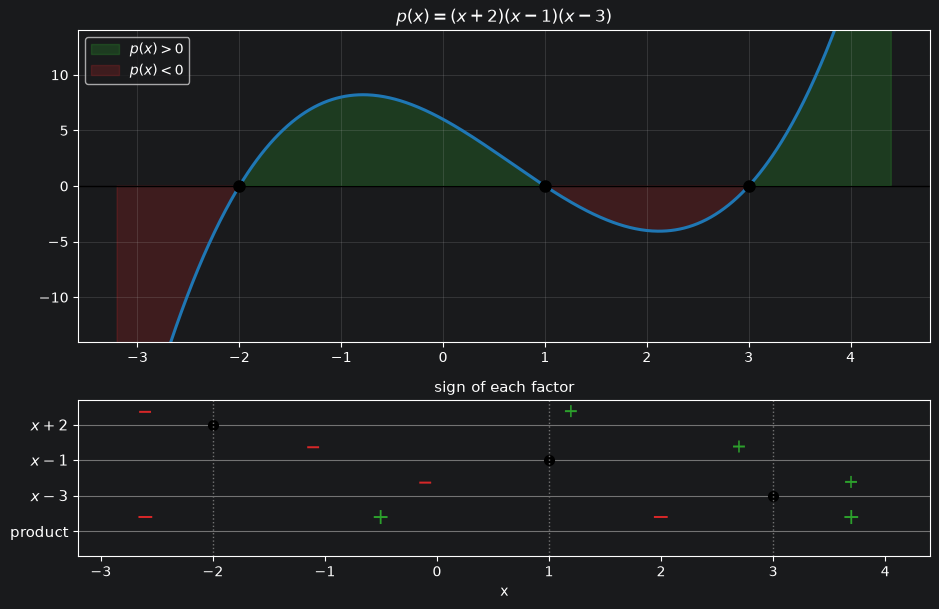

In [10]:
# --- picture: the sign chart, drawn ---

x = np.linspace(-3.2, 4.4, 700)
p = (x + 2) * (x - 1) * (x - 3)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 6.2),
                               gridspec_kw={"height_ratios": [3, 1.5]})

# ---- top: the graph, with the positive part shaded green and the negative part red ----
ax1.plot(x, p, color=C_MAIN, linewidth=2.2)
ax1.fill_between(x, p, 0, where=(p > 0), color=C_FILL, alpha=0.25, label="$p(x)>0$")
ax1.fill_between(x, p, 0, where=(p < 0), color=C_ALT,  alpha=0.20, label="$p(x)<0$")
ax1.axhline(0, color="black", linewidth=1)
ax1.plot([-2, 1, 3], [0, 0, 0], "o", color="black", markersize=8, zorder=5)
ax1.set_ylim(-14, 14)
ax1.set_title(r"$p(x)=(x+2)(x-1)(x-3)$")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.25)

# ---- bottom: the sign of each bracket, row by row ----
rows = [(r"$x+2$", -2), (r"$x-1$", 1), (r"$x-3$", 3)]
for i, (name, root) in enumerate(rows):
    y0 = -i                                        # one row per bracket, going down
    ax2.plot([-3.2, 4.4], [y0, y0], color=C_GREY, linewidth=0.8)
    ax2.plot(root, y0, "o", color="black", markersize=7)
    # a minus sign to the left of the root, a plus sign to the right
    ax2.text((-3.2 + root)/2, y0 + 0.20, "$-$", ha="center", fontsize=14, color=C_ALT)
    ax2.text((root + 4.4)/2, y0 + 0.20, "$+$", ha="center", fontsize=14, color=C_FILL)

# the product row
y0 = -3
ax2.plot([-3.2, 4.4], [y0, y0], color=C_GREY, linewidth=0.8)
for (lo, hi, sign) in [(-3.2, -2, "$-$"), (-2, 1, "$+$"), (1, 3, "$-$"), (3, 4.4, "$+$")]:
    col = C_FILL if sign == "$+$" else C_ALT
    ax2.text((lo + hi)/2, y0 + 0.20, sign, ha="center", fontsize=16, color=col)
for r in (-2, 1, 3):
    ax2.axvline(r, color=C_GREY, linestyle=":", linewidth=1)

ax2.set_xlim(-3.2, 4.4)
ax2.set_ylim(-3.7, 0.7)
# put the row names on the y-axis, so nothing sticks out of the picture
ax2.set_yticks([0, -1, -2, -3])
ax2.set_yticklabels([r"$x+2$", r"$x-1$", r"$x-3$", "product"], fontsize=11)
ax2.set_xlabel("x")
ax2.set_title("sign of each factor", fontsize=11)
plt.tight_layout()
plt.show()


---

## 6. Python demonstrations

Two libraries, same as before:

* **SymPy** does *exact symbolic* algebra — it works with the letters themselves, like a
  very patient mathematician. It will be our marker: whatever we factor by hand, SymPy
  confirms.
* **NumPy** does *fast approximate numbers*. At the end it will show us something SymPy
  cannot: that factoring is dangerous when the numbers are not exact.

### 6.1 A tour of SymPy's factoring commands


In [11]:
import sympy as sp        # sp = SymPy, the exact-algebra tool

x, y, a, b = sp.symbols("x y a b")   # create the letters SymPy is allowed to use

# sp.factor(expr) = "factor this completely, over the rational numbers"
print("factor(x**2 + 5*x + 6)   =", sp.factor(x**2 + 5*x + 6))
print("factor(6*x**2 - 7*x - 20)=", sp.factor(6*x**2 - 7*x - 20))
print("factor(x**4 - 81)        =", sp.factor(x**4 - 81))
print("factor(54*x**3 - 16)     =", sp.factor(54*x**3 - 16))
print("factor(2*x**3-3*x**2-11*x+6) =", sp.factor(2*x**3 - 3*x**2 - 11*x + 6))

# sp.expand(expr) = the opposite direction: multiply everything out
print()
print("expand((x-3)*(2*x-1)*(x+2)) =", sp.expand((x - 3)*(2*x - 1)*(x + 2)))


factor(x**2 + 5*x + 6)   = (x + 2)*(x + 3)
factor(6*x**2 - 7*x - 20)= (2*x - 5)*(3*x + 4)
factor(x**4 - 81)        = (x - 3)*(x + 3)*(x**2 + 9)
factor(54*x**3 - 16)     = 2*(3*x - 2)*(9*x**2 + 6*x + 4)
factor(2*x**3-3*x**2-11*x+6) = (x - 3)*(x + 2)*(2*x - 1)

expand((x-3)*(2*x-1)*(x+2)) = 2*x**3 - 3*x**2 - 11*x + 6


In [12]:
# sp.factor_list gives the answer as DATA, not as a picture:
#   (constant, [(factor, how many times it appears), ...])
# The "how many times" is exactly the MULTIPLICITY of Definition 8.
const, pieces = sp.factor_list(4*(x - 1)**2 * (x + 2)**3)
print("constant in front:", const)
for poly, power in pieces:
    print(f"   factor {poly}  appears {power} time(s)")


constant in front: 4
   factor x - 1  appears 2 time(s)
   factor x + 2  appears 3 time(s)


In [13]:
# Factoring in several letters works too - Theorem 4 does not care what a and b are.
print("a**2 - b**2      ->", sp.factor(a**2 - b**2))
print("a**3 + b**3      ->", sp.factor(a**3 + b**3))
print("a**3 - b**3      ->", sp.factor(a**3 - b**3))
print("x**2 + 2*x*y + y**2 ->", sp.factor(x**2 + 2*x*y + y**2))

# And the general a^n - b^n of Theorem 4(vi), for n = 5:
print("a**5 - b**5      ->", sp.factor(a**5 - b**5))


a**2 - b**2      -> (a - b)*(a + b)
a**3 + b**3      -> (a + b)*(a**2 - a*b + b**2)
a**3 - b**3      -> (a - b)*(a**2 + a*b + b**2)
x**2 + 2*x*y + y**2 -> (x + y)**2
a**5 - b**5      -> (a - b)*(a**4 + a**3*b + a**2*b**2 + a*b**3 + b**4)


### 6.2 The number system really does change the answer

Here is §1.4 and Theorem 8, but as running code. By default `factor` works over the
**rational** numbers. If we let it use $\sqrt2$, or the imaginary unit $i$, the answers
change.


In [14]:
print("over the rationals (the default):")
print("   x**2 - 2  ->", sp.factor(x**2 - 2))          # cannot be done: stays as it is
print("   x**2 + 1  ->", sp.factor(x**2 + 1))          # cannot be done either

print()
print("now allow sqrt(2)  (extension=... means 'you may also use this number'):")
print("   x**2 - 2  ->", sp.factor(x**2 - 2, extension=sp.sqrt(2)))

print()
print("now allow the imaginary unit i  (gaussian=True):")
print("   x**2 + 1  ->", sp.factor(x**2 + 1, gaussian=True))
print("   x**2 + 4  ->", sp.factor(x**2 + 4, gaussian=True))

print()
print("Trap 7 in code - no real root, but it still factors:")
print("   x**4 + 4  ->", sp.factor(x**4 + 4))          # (x^2-2x+2)(x^2+2x+2)
print("   x**4 + 1  ->", sp.factor(x**4 + 1))          # over Q: cannot be done


over the rationals (the default):
   x**2 - 2  -> x**2 - 2
   x**2 + 1  -> x**2 + 1

now allow sqrt(2)  (extension=... means 'you may also use this number'):
   x**2 - 2  -> (x - sqrt(2))*(x + sqrt(2))

now allow the imaginary unit i  (gaussian=True):
   x**2 + 1  -> (x - I)*(x + I)
   x**2 + 4  -> (x - 2*I)*(x + 2*I)

Trap 7 in code - no real root, but it still factors:
   x**4 + 4  -> (x**2 - 2*x + 2)*(x**2 + 2*x + 2)
   x**4 + 1  -> x**4 + 1


### 6.3 Building the tools ourselves

Reading a library's answer is not understanding. Let us write the three main tools in plain
Python, using only lists of coefficients — exactly the representation from notebook 04.

**Convention (same as notebook 04):** a polynomial is a list of coefficients from the
**constant term upwards**. So `[6, -11, -3, 2]` means $6-11x-3x^2+2x^3$.


In [16]:
from fractions import Fraction    # exact fractions: Fraction(1,2) is exactly one half
from math import gcd                 # gcd(a, b) = greatest common divisor of two integers

def poly_str(c):
    """Turn a coefficient list into a readable string, highest power first."""
    terms = []
    for k in range(len(c) - 1, -1, -1):
        coeff = c[k]
        if coeff == 0:                       # skip the powers that are not there
            continue
        power = "" if k == 0 else ("x" if k == 1 else f"x^{k}")
        if k > 0 and coeff == 1:             # write "x^2", not "1x^2"
            terms.append(power)
        elif k > 0 and coeff == -1:
            terms.append("-" + power)
        else:
            terms.append(f"{coeff}{power}")
    if not terms:
        return "0"
    out = terms[0]
    for t in terms[1:]:                      # join with " + " or " - " so it reads nicely
        out += (" - " + t[1:]) if t.startswith("-") else (" + " + t)
    return out


def content_and_primitive(c):
    """Split off the GCF of a list of INTEGER coefficients (Definition 6, number part
    only). Returns (gcf, remaining coefficients)."""
    g = 0
    for coeff in c:
        g = gcd(g, abs(coeff))        # gcd(0, n) = n, so this builds up the gcd of them all
    if g == 0:                        # the zero polynomial: nothing to pull out
        return 1, c
    if c[-1] < 0:                     # leading coefficient negative -> pull the minus out too
        g = -g
    return g, [coeff // g for coeff in c]


for test in ([0, 0, 30, -18, 0, 12],   # 12x^5 - 18x^3 + 30x^2, the Definition 6 example
             [12, -18, 30], [-12, 18, -30], [0, 0, 6, 9], [7, 3]):
    g, rest = content_and_primitive(test)
    print(f"{poly_str(test):<28} = {g} * ( {poly_str(rest)} )")


12x^5 - 18x^3 + 30x^2        = 6 * ( 2x^5 - 3x^3 + 5x^2 )
30x^2 - 18x + 12             = 6 * ( 5x^2 - 3x + 2 )
-30x^2 + 18x - 12            = -6 * ( 5x^2 - 3x + 2 )
9x^3 + 6x^2                  = 3 * ( 3x^3 + 2x^2 )
3x + 7                       = 1 * ( 3x + 7 )


In [17]:
def divisors(n):
    """Every positive whole number that divides n."""
    n = abs(n)
    return [d for d in range(1, n + 1) if n % d == 0]


def rational_root_candidates(c):
    """All fractions p/q allowed by Theorem 12, for integer coefficients c
    (constant term first). Returns them sorted, with no duplicates."""
    # drop any leading zeros at the top so that c[-1] is really the leading coefficient
    while len(c) > 1 and c[-1] == 0:
        c = c[:-1]
    a0, an = c[0], c[-1]
    if a0 == 0:
        # x = 0 IS a root; pull out the factor x first and try again on what is left
        raise ValueError("constant term is 0: factor out x first")
    return sorted({Fraction(s * p, q)
                   for p in divisors(a0)        # p divides the constant term
                   for q in divisors(an)        # q divides the leading coefficient
                   for s in (1, -1)})           # both signs are allowed


def horner(c, t):
    """Evaluate the polynomial at t using Horner's method (notebook 04).
    Also returns the coefficients of the quotient after dividing by (x - t):
    this IS synthetic division, the subject of notebook 06."""
    n = len(c) - 1
    quotient = [0] * n              # the quotient has degree one less
    acc = c[n]                      # start from the leading coefficient
    for k in range(n - 1, -1, -1):
        quotient[k] = acc           # what we carry down becomes a quotient coefficient
        acc = acc * t + c[k]        # multiply by t and add the next coefficient
    return acc, quotient            # acc is the REMAINDER = the value f(t)


f = [6, -11, -3, 2]                 # 2x^3 - 3x^2 - 11x + 6
print("polynomial:", poly_str(f))
print("candidates:", [str(c) for c in rational_root_candidates(f)])
print()
for cand in rational_root_candidates(f):
    value, _ = horner([Fraction(k) for k in f], cand)
    mark = "  <-- ROOT" if value == 0 else ""
    print(f"   f({str(cand):>4}) = {str(value):>6}{mark}")


polynomial: 2x^3 - 3x^2 - 11x + 6
candidates: ['-6', '-3', '-2', '-3/2', '-1', '-1/2', '1/2', '1', '3/2', '2', '3', '6']

   f(  -6) =   -468
   f(  -3) =    -42
   f(  -2) =      0  <-- ROOT
   f(-3/2) =      9
   f(  -1) =     12
   f(-1/2) =   21/2
   f( 1/2) =      0  <-- ROOT
   f(   1) =     -6
   f( 3/2) =  -21/2
   f(   2) =    -12
   f(   3) =      0  <-- ROOT
   f(   6) =    264


In [18]:
def factor_rational_roots(c):
    """Peel off every rational root (Theorem 9 + Theorem 12).
    Returns (list of roots found, coefficients of what is left over)."""
    c = [Fraction(k) for k in c]
    roots = []

    # first: pull out any factor of x (that is the root 0), so the constant term is not 0
    while len(c) > 1 and c[0] == 0:
        roots.append(Fraction(0))
        c = c[1:]                       # dropping the constant term IS dividing by x

    changed = True
    while changed and len(c) > 2:       # stop at degree <= 1, nothing left to search
        changed = False
        ints = [int(k * _lcm_den(c)) for k in c]     # make the coefficients whole numbers
        for cand in rational_root_candidates(ints):
            value, q = horner(c, cand)
            if value == 0:
                roots.append(cand)
                c = q                   # continue with the quotient
                changed = True
                break                   # start the search again on the smaller polynomial
    return roots, c


def _lcm_den(c):
    """Smallest number that clears all the denominators in a list of Fractions."""
    from math import lcm
    d = 1
    for k in c:
        d = lcm(d, k.denominator)
    return d


for test in ([6, -11, -3, 2],        # 2x^3 - 3x^2 - 11x + 6
             [4, 0, -5, 0, 1],       # x^4 - 5x^2 + 4
             [0, 600, -100, 4],      # the open box: 4x^3 - 100x^2 + 600x
             [1, 0, 1]):             # x^2 + 1  -> no rational root at all
    roots, left = factor_rational_roots(test)
    found = ", ".join(str(r) for r in roots) or "(none)"
    print(f"{poly_str(test):<28} roots found: {found:<22} left over: {poly_str(left)}")


2x^3 - 3x^2 - 11x + 6        roots found: -2, 1/2                left over: 2x - 6
x^4 - 5x^2 + 4               roots found: -2, -1, 1              left over: x - 2
4x^3 - 100x^2 + 600x         roots found: 0, 10                  left over: 4x - 60
x^2 + 1                      roots found: (none)                 left over: x^2 + 1


In [19]:
# Check our home-made factoriser against SymPy, so we know it is right.
tests = [[6, -11, -3, 2], [4, 0, -5, 0, 1], [0, 600, -100, 4], [1, 0, 1], [-16, 0, 0, 0, 1]]

for c in tests:
    # rebuild the polynomial as a SymPy expression from the coefficient list
    expr = sum(coeff * x**k for k, coeff in enumerate(c))
    roots, left = factor_rational_roots(c)

    # rebuild OUR answer as a product and expand it: it must equal the original
    rebuilt = sum(coeff * x**k for k, coeff in enumerate(left))
    for r in roots:
        rebuilt = rebuilt * (x - sp.Rational(r.numerator, r.denominator))

    same = sp.expand(rebuilt - expr) == 0      # zero difference = the same polynomial
    print(f"{str(expr):<28} ours matches SymPy: {same}      SymPy: {sp.factor(expr)}")


2*x**3 - 3*x**2 - 11*x + 6   ours matches SymPy: True      SymPy: (x - 3)*(x + 2)*(2*x - 1)
x**4 - 5*x**2 + 4            ours matches SymPy: True      SymPy: (x - 2)*(x - 1)*(x + 1)*(x + 2)
4*x**3 - 100*x**2 + 600*x    ours matches SymPy: True      SymPy: 4*x*(x - 15)*(x - 10)
x**2 + 1                     ours matches SymPy: True      SymPy: x**2 + 1
x**4 - 16                    ours matches SymPy: True      SymPy: (x - 2)*(x + 2)*(x**2 + 4)


### 6.4 Checking the identities of Theorem 4 symbolically

A check is not a proof (we proved these in §3.4). But a check catches typing mistakes, and
it shows you how to ask SymPy "are these two expressions the same?" — the right way is to
**subtract them and simplify to zero**, never to compare them as text.


In [20]:
identities = [
    ("a^2-b^2 = (a-b)(a+b)",              a**2 - b**2,             (a - b)*(a + b)),
    ("a^2+2ab+b^2 = (a+b)^2",             a**2 + 2*a*b + b**2,     (a + b)**2),
    ("a^2-2ab+b^2 = (a-b)^2",             a**2 - 2*a*b + b**2,     (a - b)**2),
    ("a^3-b^3 = (a-b)(a^2+ab+b^2)",       a**3 - b**3,             (a - b)*(a**2 + a*b + b**2)),
    ("a^3+b^3 = (a+b)(a^2-ab+b^2)",       a**3 + b**3,             (a + b)*(a**2 - a*b + b**2)),
    ("a^4-b^4 = (a-b)(a^3+a^2b+ab^2+b^3)", a**4 - b**4,
     (a - b)*(a**3 + a**2*b + a*b**2 + b**3)),
]

for name, left, right in identities:
    # sp.simplify(left - right) == 0  means "the difference is really zero"
    ok = sp.simplify(left - right) == 0
    print(f"{name:<40} {'OK' if ok else 'WRONG'}")


a^2-b^2 = (a-b)(a+b)                     OK
a^2+2ab+b^2 = (a+b)^2                    OK
a^2-2ab+b^2 = (a-b)^2                    OK
a^3-b^3 = (a-b)(a^2+ab+b^2)              OK
a^3+b^3 = (a+b)(a^2-ab+b^2)              OK
a^4-b^4 = (a-b)(a^3+a^2b+ab^2+b^3)       OK


In [21]:
# The discriminant test of Theorem 8, as a small function.
def real_quadratic_verdict(A, B, C):
    """Say whether A x^2 + B x + C factors over the real numbers, and how."""
    D = B**2 - 4*A*C
    if D > 0:
        r1 = sp.nsimplify((-B + sp.sqrt(D)) / (2*A))   # nsimplify keeps roots exact
        r2 = sp.nsimplify((-B - sp.sqrt(D)) / (2*A))
        return f"D = {D} > 0  -> reducible: {A}*(x - ({r1}))*(x - ({r2}))"
    if D == 0:
        r = sp.nsimplify(-B / (2*A))
        return f"D = 0        -> perfect square: {A}*(x - ({r}))^2"
    return f"D = {D} < 0  -> IRREDUCIBLE over R"

for (A, B, C) in [(1, -2, -1), (1, -2, 1), (1, -2, 2), (1, 0, 1), (9, 6, 4), (6, -7, -20)]:
    name = poly_str([C, B, A])          # reuse our printer: [constant, x, x^2]
    print(f"{name}:".ljust(22), real_quadratic_verdict(A, B, C))


x^2 - 2x - 1:          D = 8 > 0  -> reducible: 1*(x - (1 + sqrt(2)))*(x - (1 - sqrt(2)))
x^2 - 2x + 1:          D = 0        -> perfect square: 1*(x - (1))^2
x^2 - 2x + 2:          D = -4 < 0  -> IRREDUCIBLE over R
x^2 + 1:               D = -4 < 0  -> IRREDUCIBLE over R
9x^2 + 6x + 4:         D = -108 < 0  -> IRREDUCIBLE over R
6x^2 - 7x - 20:        D = 529 > 0  -> reducible: 6*(x - (5/2))*(x - (-4/3))


### 6.5 The warning: factoring is numerically dangerous

Everything above was **exact**: whole numbers and fractions, no rounding. Real scientific
computing is not exact — a computer stores numbers with about 16 digits and throws the rest
away.

Here is what that does to factoring. Take the polynomial whose roots are exactly
$1,2,3,\dots,15$:

$$W(x)=(x-1)(x-2)\cdots(x-15).$$

Multiply it out, then change **one** coefficient by a relative amount of about
$10^{-9}$ — that is a change in the ninth decimal place, far smaller than any measurement
error in any real experiment. Then ask a computer for the roots again.

They do not move a little. Some of them **leave the real line completely** and become
complex numbers.

This is called an **ill-conditioned** problem: *"small change in the input, huge change in
the output"*. It is the most important idea in numerical analysis, and it is the reason
professional software almost never solves a polynomial by expanding it first. (This is the
same lesson as the $(x-1)^7$ experiment in notebook 04, but much louder.)


In [22]:
# np.poly(roots) does the opposite of factoring: it multiplies (x-r) together
# and returns the coefficient list, HIGHEST power first.
true_roots = np.arange(1, 16)              # the numbers 1, 2, ..., 15
coeffs = np.poly(true_roots)               # the expanded polynomial W(x)

print("degree:", len(coeffs) - 1)
print("first few coefficients:", coeffs[:4])

# np.roots(coeffs) does the factoring: it finds the roots from the coefficients.
back = np.roots(coeffs)
print("\nbiggest error when we go there and back with NO change:",
      np.max(np.abs(np.sort(back.real) - true_roots)))

# --- now the tiny change ---
perturbed = coeffs.copy()
perturbed[1] *= (1 + 1e-9)                 # change the x^14 coefficient in the 9th digit
bad = np.roots(perturbed)

print("\nrelative size of the change we made: 1e-9")
print("largest imaginary part of the new roots:", np.max(np.abs(bad.imag)))
print("largest movement of a root:            ",
      np.max(np.abs(np.sort_complex(bad) - np.sort_complex(back))))


degree: 15
first few coefficients: [ 1.000e+00 -1.200e+02  6.580e+03 -2.184e+05]

biggest error when we go there and back with NO change: 4.874264762477765e-06

relative size of the change we made: 1e-9
largest imaginary part of the new roots: 0.41762178033240743
largest movement of a root:             0.6782589525132263


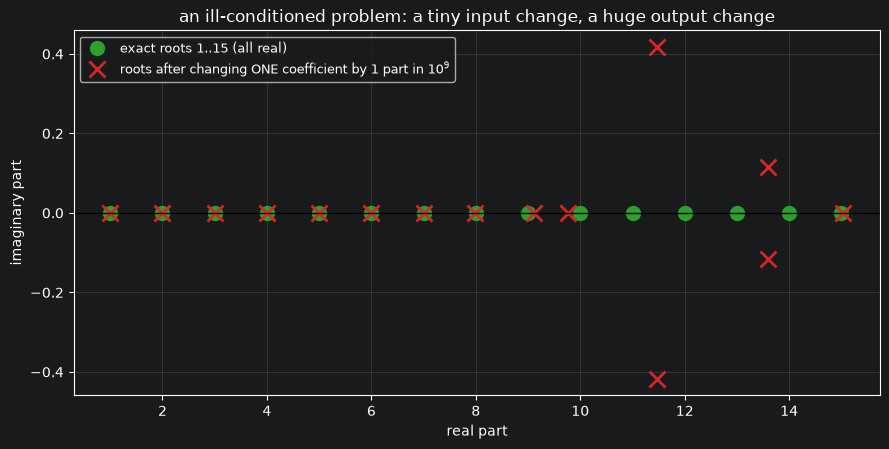

In [23]:
# --- picture: where the roots went ---

fig, ax = plt.subplots(figsize=(9, 4.6))

ax.plot(true_roots, np.zeros_like(true_roots), "o", color=C_FILL, markersize=10,
        label="exact roots 1..15 (all real)")
ax.plot(bad.real, bad.imag, "x", color=C_ALT, markersize=11, markeredgewidth=2,
        label="roots after changing ONE coefficient by 1 part in $10^{9}$")

ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("an ill-conditioned problem: a tiny input change, a huge output change")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Read the picture carefully.** The green dots are where the roots really are. The red
crosses are where a computer thinks they are after a change in the ninth digit. The middle
roots have flown off the real line into the complex plane.

**The moral, and it is a permanent one:**

> Exact algebra (SymPy, fractions, your pencil) and floating-point numbers (NumPy) are two
> different worlds. Factoring by hand is exact and safe. Factoring a *measured* polynomial
> numerically is a trap. When you meet this again in machine learning — and you will, as
> "the condition number of a matrix" — remember these red crosses.


---

## 7. Exercises

Twenty of them, easy to hard. Do them **with a pencil first**; use SymPy only to check
after you have an answer. Write your work in the empty cells.

Three rules for every factoring exercise:

1. GCF first.
2. Keep going until every bracket is irreducible.
3. **Multiply back** and check. Or put $x=1$ in both forms — they must give the same number.

Exercises 11–13 are Python. Exercises 17–20 are proofs: write full sentences, and name the
theorem you use at each step.

---

### Exercise 1 — pull out the GCF

Factor out the greatest common factor.

(a) $6x^3+9x^2$  (b) $4x^4y-8x^2y^2+12x^2y$  (c) $-5x^2+10x$  (d) $8x^3-12x^2+20x$

*(In (c), pull the minus sign out as well.)*


In [ ]:
# your work for Exercise 1


### Exercise 2 — grouping

Factor by grouping.

(a) $x^3+x^2+2x+2$  (b) $2x^3-x^2+6x-3$  (c) $3xy-6x+2y-4$  (d) $x^3-5x^2-4x+20$


In [ ]:
# your work for Exercise 2


### Exercise 3 — difference of squares

Factor completely.

(a) $9x^2-49$  (b) $x^4-81$  (c) $50-2y^2$  (d) $16x^4-1$

*(Watch out: one of these needs a GCF first, and one needs the rule twice.)*


In [ ]:
# your work for Exercise 3


### Exercise 4 — monic trinomials

Factor.

(a) $x^2+7x+12$  (b) $x^2-x-20$  (c) $x^2-9x+18$  (d) $x^2+4x+5$

*(One of these does not factor over the integers. Say **which**, and prove it with
Theorem 8.)*


In [ ]:
# your work for Exercise 4


### Exercise 5 — non-monic trinomials

Factor with the $ac$ method.

(a) $6x^2+7x-3$  (b) $4x^2-4x-15$  (c) $3x^2-10x+8$  (d) $10x^2+11x-6$

For (a), also write down the numbers $m$ and $n$ from Theorem 6 and check that
$m+n=b$ and $mn=ac$.


In [ ]:
# your work for Exercise 5


### Exercise 6 — perfect squares, real and fake

Which of these are perfect squares? Factor each one completely.

(a) $9x^2-24x+16$  (b) $x^2+x+\tfrac14$  (c) $4x^2+9$  (d) $25x^2-30x+8$

*(For each one, first check the middle term against $2ab$, as in Example 6.)*


In [ ]:
# your work for Exercise 6


### Exercise 7 — cubes

Factor completely.

(a) $8x^3-27$  (b) $x^3+64$  (c) $27a^3+125b^3$  (d) $2x^4-16x$

For (a), also show with the discriminant that the long bracket cannot be factored further
over $\mathbb{R}$.


In [ ]:
# your work for Exercise 7


### Exercise 8 — factor completely (mixed, several steps each)

(a) $x^4-16$  (b) $3x^3-27x$  (c) $x^4-5x^2+4$  (d) $2x^5-32x$  (e) $x^6-64$

For (e), do it **two ways**: first as a difference of squares $\big((x^3)^2-8^2\big)$, and
then as a difference of cubes $\big((x^2)^3-4^3\big)$. You must get the same final answer —
Theorem 16 says so. Write one sentence explaining how you reconciled the two routes.


In [ ]:
# your work for Exercise 8


### Exercise 9 — find a root, then peel

Factor $\;x^3-4x^2+x+6\;$ completely.

Method: it is monic with integer coefficients, so by **Corollary 13** any rational root is
an integer dividing $6$. Test $\pm1,\pm2,\pm3,\pm6$, then use Theorem 9 to divide out the
factor you find, and finish the quadratic.


In [ ]:
# your work for Exercise 9


### Exercise 10 — the full rational root theorem

For $\;f(x)=2x^3+3x^2-8x+3$:

(a) Write down **all** the candidates given by Theorem 12. How many are there?
(b) Test them and find every rational root.
(c) Factor $f$ completely.
(d) Explain in one sentence why the theorem lets you stop searching after that finite list,
even though there are infinitely many fractions.


In [ ]:
# your work for Exercise 10


### Exercise 11 — Python: your own GCF extractor

Write a function `pull_out_gcf(coeffs)` that takes a list of **integer** coefficients
(constant term first, like `[12, -18, 30]`), and returns

* the GCF as a pair `(number_part, lowest_power_of_x)`, and
* the coefficient list of what is left.

Rules: if the leading coefficient is negative, the number part must be negative too. Test it
on `[12, -18, 30]`, `[0, 0, 6, 9]` and `[-4, 8, -12]`, and check each answer against
`sp.factor`.


In [ ]:
# your work for Exercise 11


### Exercise 12 — Python: your own rational root finder

Write `find_rational_roots(coeffs)` that returns every rational root of an integer
polynomial, **using exact `Fraction` arithmetic** (never floats).

Then answer with an experiment: for $f(x)=6x^3-x^2-5x+2$, how many candidates does
Theorem 12 produce, and how many of them are actually roots? Print both numbers.

Finally, explain in one or two sentences what would go wrong if you used floating-point
numbers instead of `Fraction` — try it and show the output.


In [ ]:
# your work for Exercise 12


### Exercise 13 — Python: graph and factorisation must agree

Take $\;g(x)=(x+3)(x-1)^2(x-4)$.

(a) Expand it with SymPy and print the coefficient list.
(b) Plot it with matplotlib on $-4\le x\le5$, mark every root, and shade where $g(x)>0$.
(c) From the picture alone, say which root is the double one, and explain how you can tell.
(d) Build the sign chart (like Example 12) and solve $g(x)\le0$.


In [ ]:
# your work for Exercise 13


### Exercise 14 — solve by factoring

Solve each equation. Show the factored form you used.

(a) $x^2=5x-6$  (b) $x^3=4x$  (c) $(x+1)(x-3)=5$  (d) $2x^3-3x^2-11x+6=0$

*(In (b), do **not** divide both sides by $x$ — that throws away a solution. Why? Say
exactly which theorem you would be breaking.)*


In [ ]:
# your work for Exercise 14


### Exercise 15 — a real problem

A rectangular garden is $3$ m longer than it is wide. Its area is $70\ \text{m}^2$.

(a) Let $w$ be the width. Write an equation for $w$.
(b) Solve it by factoring.
(c) Your factorisation gives two numbers. One of them is not an answer. Say which, and why.
(d) Now do the same for the open box of Example 11: using $V(x)=4x(x-10)(x-15)$, find the
values of $x$ that give $V(x)=0$, and explain in your own words why the domain is
$0<x<10$ and not $0<x<15$.


In [ ]:
# your work for Exercise 15


### Exercise 16 — the number system matters

(a) Factor $x^2-5$ over $\mathbb{Q}$, then over $\mathbb{R}$. Which one is impossible, and
which notebook-01 theorem proves it?
(b) Factor $x^4-4$ completely over $\mathbb{Q}$, and then over $\mathbb{R}$.
(c) $x^4-4$ has **no rational root**. Explain why that does **not** mean it is irreducible
over $\mathbb{Q}$. (Compare with Trap 7.)
(d) Check all of (a)–(b) with SymPy, using `extension=` where you need it.


In [ ]:
# your work for Exercise 16


### Exercise 17 — proof: the sum of cubes, and why the long bracket is irreducible

(a) Prove the identity $\;a^3+b^3=(a+b)(a^2-ab+b^2)\;$ by expanding the right-hand side.
Name the axiom you use at each step (distributivity, commutativity).

(b) Prove that $\;a^2-ab+b^2>0\;$ for all real $a,b$ **except** $a=b=0$.

*Hint for (b): complete the square in $a$, treating $b$ as a constant. You should reach*
$$a^2-ab+b^2=\left(a-\frac{b}{2}\right)^{2}+\frac{3b^{2}}{4},$$
*and then argue about the sign of each piece. Explain also why the two pieces cannot both be
zero unless $a=b=0$.*

(c) Use (b) to explain why $a^3+b^3$ and $a+b$ always have the same sign.


In [ ]:
# your work for Exercise 17


### Exercise 18 — proof: when does $x^2+bx+c$ factor over the integers?

Let $b,c$ be **integers**. Prove:

$$x^2+bx+c=(x+p)(x+q)\ \text{ for some integers } p,q
\quad\Longleftrightarrow\quad b^2-4c \text{ is the square of an integer.}$$

*Plan for the forward direction ($\Rightarrow$):* start from $p+q=b$ and $pq=c$
(Theorem 5) and compute $(p-q)^2$ in terms of $b$ and $c$.

*Plan for the backward direction ($\Leftarrow$):* if $b^2-4c=k^2$ with $k$ an integer, set
$p=\frac{b+k}{2}$ and $q=\frac{b-k}{2}$, then check that $p+q=b$ and $pq=c$. The delicate
part is showing $p$ and $q$ are **integers** and not halves — for that, prove first that
$k$ and $b$ are both even or both odd. *(Hint: $k^2-b^2=-4c$ is a multiple of $4$; think
about what $k^2-b^2$ looks like when one of them is even and the other is odd.)*


In [ ]:
# your work for Exercise 18


### Exercise 19 — proof: the rational root theorem as an irrationality machine

(a) Prove Corollary 13 in your own words: if a monic polynomial with integer coefficients
has a rational root, that root is an integer, and it divides the constant term.

(b) Use it to prove that $\sqrt[3]{2}$ is **irrational**. (Start by writing down a monic
integer polynomial that has $\sqrt[3]{2}$ as a root.)

(c) Use it to prove that $\sqrt{7}$ is irrational, without repeating the even/odd argument
of notebook 01.

(d) State the general result your argument proves: *if $m$ and $n$ are positive integers and
$\sqrt[n]{m}$ is not an integer, then it is …* — and give the one-line reason.


In [ ]:
# your work for Exercise 19


### Exercise 20 — proof: no real root does **not** mean irreducible

This is the capstone. Work through it slowly.

(a) Prove that $\;x^4+4=(x^2-2x+2)(x^2+2x+2)\;$ by expanding the right-hand side.

*(If you want to see where it comes from rather than just checking it: add and subtract
$4x^2$, so that $x^4+4=(x^4+4x^2+4)-4x^2=(x^2+2)^2-(2x)^2$, and then use the difference of
squares.)*

(b) Prove that $x^4+4>0$ for every real $x$, so $x^4+4$ has **no real root at all**.

(c) Prove that each of the two quadratic factors is **irreducible over $\mathbb{R}$**, using
Theorem 8.

(d) Now write two or three sentences explaining the moral: why does "$f$ has no real root"
prove irreducibility when $\deg f\le3$, but not when $\deg f=4$? *(Think about what degrees
the two pieces of a factorisation could have, and use the degree rule of notebook 04,
Theorem 2.)*


In [ ]:
# your work for Exercise 20


---

## 8. Running this notebook with `uv`

This project is managed by **`uv`**, a fast tool that installs the right Python and the
right libraries for you.

```bash
uv sync           # install everything listed in pyproject.toml (numpy, sympy, matplotlib, jupyterlab)
uv run jupyter lab   # start Jupyter Lab and open this notebook
```

Inside Jupyter, **Run → Restart Kernel and Run All Cells** re-runs the whole notebook from
the top. It must work every time, with no errors. If a cell fails, the notebook is broken —
tell me.

No new library was needed for this notebook. If a future notebook needs one:

```bash
uv add pandas     # example only - never import a package before adding it here
```

---

## 9. What we owe, and what comes next

**Still owed (honest list).**

* We proved *when a quadratic* is irreducible over $\mathbb{R}$ (Theorem 8). We have **not**
  proved the big structure theorem: *every real polynomial factors into linear pieces and
  irreducible quadratics*. That needs the **fundamental theorem of algebra**, which needs
  complex numbers — syllabus topic "Complex Numbers".
* The rational root theorem finds only the *rational* roots. Irrational roots such as
  $\sqrt2$ or $\sqrt[3]{2}$ are invisible to it. For degree $\le4$ there are formulas; for
  degree $\ge5$ **there is no formula at all** built from $+,-,\times,\div$ and roots. That
  is Abel's theorem, one of the great results of the 19th century, and we will not prove it
  in this course.
* We have not touched *how a computer factors quickly* (Berlekamp's and Zassenhaus'
  algorithms). SymPy's `factor` uses them.

**Next topic in the syllabus: Synthetic Division.** You have already met it without knowing
— the `horner` function in §6.3 returned both a value **and** a quotient. That is exactly
synthetic division. Next notebook makes it official, and shows why the whole table of
numbers you will write down is just Horner's method wearing different clothes.
